 Python Version == 3.11.2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
raw_data = [
    [250, 16, 12, "Excellent"],    
    [200,  16, 8, "Average"],     
    [300, 32, 16, "Good"],         
    [275,  32,  8, "Good"],        
    [225, 16, 16, "Below Average"], 
    [320, 64, 20, "Excellent"],   
    [180, 8, 12, "Poor"],          
    [290, 32, 24, "Excellent"],    
    [240, 16, 16, "Good"],        
    [350, 64, 8, "Average"]        
]
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}
# Convert to numeric, especially for the "Link Quality" column
encoded_data = []
for row in raw_data:
    battery_capacity    = row[0]
    environmental  = row[1]
    bandwidth   = row[2]
    link_quality   = looks_mapping[row[3]]  # Convert text to numeric
    encoded_data.append([battery_capacity, environmental, bandwidth, link_quality])

data = np.array(encoded_data, dtype=float)
print("Encoded Data Matrix:\n", data)

Encoded Data Matrix:
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]]


In [5]:
is_beneficial = [True, False, True,True]
# Assuming that battery , bandwith and link quality are beneficial( that mean they must be maximised)
#  and environmental is non beneficial ( that mean it must be minimised)


In [6]:
# -------------------------------
# 1. Linear (Min-Max) Normalization
# -------------------------------
def min_max_normalization(data, is_beneficial):
    """
    For beneficial criteria: r = (x - min)/(max - min)
    For non-beneficial criteria: r = (max - x)/(max - min)
    """
    norm_data = np.zeros_like(data, dtype=float)
    n = data.shape[1]
    for j in range(n):
        col_min = np.min(data[:, j])
        col_max = np.max(data[:, j])
        range_val = col_max - col_min
        if range_val == 0:  # when all values are same like [5,5,5,5]
            norm_data[:, j] = 0.0  # Avoid division by zero
        else:
            if is_beneficial[j]:
                norm_data[:, j] = (data[:, j] - col_min) / range_val
            else:
                norm_data[:, j] = (col_max - data[:, j]) / range_val
    return norm_data


In [7]:
# -------------------------------
# 2. Vector Normalization
# -------------------------------
def vector_normalization(data, is_beneficial):
    """
    For beneficial criteria: r = x / sqrt(sum(x^2))
    For non-beneficial criteria: r = 1 - (x / sqrt(sum(x^2)))
    """
    norm_data = np.zeros_like(data, dtype=float)
    n = data.shape[1]
    for j in range(n):
        col_values = data[:, j]
        denominator = np.sqrt(np.sum(col_values**2))
        
        if denominator == 0:
            norm_data[:, j] = 0.0
        else:
            # Normalize the column values
            normalized_values = col_values / denominator
            
            # For beneficial criteria, use the normalized values directly
            # For non-beneficial criteria, use 1 - normalized values
            if is_beneficial[j]:
                norm_data[:, j] = normalized_values
            else:
                norm_data[:, j] = 1 - normalized_values
                
    return norm_data


In [9]:
# # Firstly group all the attributes of particular into a single node
# nodes=group_all_atrribute(data)
# # Now comes the point of priotising,
# #  since there could a possibility of having a attribute
# #  which needs min value and one maxmimum value both at same time moment. 
# # so for that what we can do is make all the attribute which are 
# # benefical ( maximum value ) we would represent them as negtive value
# #  and one which needs to no - beneifical keep it unchanged.
# # and then simply push values into min - heap so we would our desired value as per our need.
# heap= heap_tranform(nodes)


In [10]:

# -------------------------------
# 3. Logarithmic 
# -------------------------------
def log_normalization(data, is_beneficial):
    """
    For beneficial criteria: r = ln(x) / ln(max)
    For non-beneficial criteria: r = 1 - ln(x) / ln(max)
    Assumes all x > 0.
    """
    norm_data = np.zeros_like(data, dtype=float)
    n = data.shape[1]
    for j in range(n):
        col_max = np.max(data[:, j])
        if col_max <= 0:
            raise ValueError(f"Column {j} has non-positive maximum, cannot perform log normalization.")
        if is_beneficial[j]:
            norm_data[:, j] = np.log10(data[:, j]) / np.log10(col_max)
        else:
            norm_data[:, j] = 1 - (np.log10(data[:, j]) / np.log10(col_max))
    return norm_data

# With base e
# Logarithmic Normalization:
# [[0.94256127 0.33333333 0.78189571 1.        ]
#  [0.90446873 0.33333333 0.65431288 0.68260619]
#  [0.97368514 0.16666667 0.87241717 0.86135312]
#  [0.95883155 0.16666667 0.65431288 0.86135312]
#  [0.92457532 0.33333333 0.87241717 0.43067656]
#  [0.98470243 0.         0.94263107 1.        ]
#  [0.88648278 0.5        0.78189571 0.        ]
#  [0.96789785 0.16666667 1.         1.        ]
#  [0.9355926  0.33333333 0.87241717 0.86135312]
#  [1.         0.         0.65431288 0.68260619]]

# With base 10 
# [[0.94256127 0.33333333 0.78189571 1.        ]
#  [0.90446873 0.33333333 0.65431288 0.68260619]
#  [0.97368514 0.16666667 0.87241717 0.86135312]
#  [0.95883155 0.16666667 0.65431288 0.86135312]
#  [0.92457532 0.33333333 0.87241717 0.43067656]
#  [0.98470243 0.         0.94263107 1.        ]
#  [0.88648278 0.5        0.78189571 0.        ]
#  [0.96789785 0.16666667 1.         1.        ]
#  [0.9355926  0.33333333 0.87241717 0.86135312]
#  [1.         0.         0.65431288 0.68260619]]


In [11]:
# -------------------------------
# 4. Enhanced Accuracy Normalization
# (Often similar to min-max but with a small alpha added to reduce sensitivity)
# -------------------------------
def enhanced_accuracy_normalization(data, is_beneficial, alpha=1e-3):
    """
    For beneficial criteria: r = (x - min)/(max - min + alpha)
    For non-beneficial criteria: r = (max - x)/(max - min + alpha)
    """
    norm_data = np.zeros_like(data, dtype=float)
    n = data.shape[1]
    for j in range(n):
        col_min = np.min(data[:, j])
        col_max = np.max(data[:, j])
        range_val = col_max - col_min + alpha  # Adding alpha for enhanced accuracy
        if is_beneficial[j]:
            norm_data[:, j] = (data[:, j] - col_min) / range_val
        else:
            norm_data[:, j] = (col_max - data[:, j]) / range_val
    return norm_data


In [12]:
min_max_norm = min_max_normalization(data, is_beneficial)
vector_norm = vector_normalization(data, is_beneficial)
log_norm = log_normalization(data, is_beneficial)
enh_norm = enhanced_accuracy_normalization(data, is_beneficial)

print("Min-Max Normalization:")
print(min_max_norm)
print("\nVector Normalization:")
print(vector_norm)
print("\nLogarithmic Normalization:")
print(log_norm)
print("\nEnhanced Accuracy Normalization:")
print(enh_norm)


Min-Max Normalization:
[[0.41176471 0.85714286 0.25       1.        ]
 [0.11764706 0.85714286 0.         0.5       ]
 [0.70588235 0.57142857 0.5        0.75      ]
 [0.55882353 0.57142857 0.         0.75      ]
 [0.26470588 0.85714286 0.5        0.25      ]
 [0.82352941 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.64705882 0.57142857 1.         1.        ]
 [0.35294118 0.85714286 0.5        0.75      ]
 [1.         0.         0.         0.5       ]]

Vector Normalization:
[[0.29508926 0.85603685 0.25445668 0.41380294]
 [0.23607141 0.85603685 0.16963779 0.24828177]
 [0.35410712 0.7120737  0.33927557 0.33104236]
 [0.32459819 0.7120737  0.16963779 0.33104236]
 [0.26558034 0.85603685 0.33927557 0.16552118]
 [0.37771426 0.4241474  0.42409446 0.41380294]
 [0.21246427 0.92801842 0.25445668 0.08276059]
 [0.34230355 0.7120737  0.50891336 0.41380294]
 [0.28328569 0.85603685 0.33927557 0.33104236]
 [0.41312497 0.4241474  0.16963779 0.24828177]]

Logarithmic

In [13]:
weights_raw = np.array([25, 25, 25, 25], dtype=float)
weights = weights_raw / np.sum(weights_raw) 
weights_x=log_norm*weights
weights_x

array([[0.23564032, 0.08333333, 0.19547393, 0.25      ],
       [0.22611718, 0.08333333, 0.16357822, 0.17065155],
       [0.24342129, 0.04166667, 0.21810429, 0.21533828],
       [0.23970789, 0.04166667, 0.16357822, 0.21533828],
       [0.23114383, 0.08333333, 0.21810429, 0.10766914],
       [0.24617561, 0.        , 0.23565777, 0.25      ],
       [0.22162069, 0.125     , 0.19547393, 0.        ],
       [0.24197446, 0.04166667, 0.25      , 0.25      ],
       [0.23389815, 0.08333333, 0.21810429, 0.21533828],
       [0.25      , 0.        , 0.16357822, 0.17065155]])

In [14]:
ideal_best = []
ideal_worst = []

for j in range(weights_x.shape[1]):
    if is_beneficial[j]:
        ideal_best.append(np.max(weights_x[:, j]))
        ideal_worst.append(np.min(weights_x[:, j]))
    else:
        ideal_best.append(np.min(weights_x[:, j]))
        ideal_worst.append(np.max(weights_x[:, j]))

ideal_best = np.array(ideal_best)
ideal_worst = np.array(ideal_worst)

ideal_best
ideal_worst


array([0.22162069, 0.125     , 0.16357822, 0.        ])

In [15]:
s_plus = np.sqrt(np.sum((weights_x - ideal_best) ** 2, axis=1))
s_minus = np.sqrt(np.sum((weights_x - ideal_worst) ** 2, axis=1))
s_minus
performance_score = s_minus / (s_plus + s_minus)
performance_score

array([0.7177244 , 0.54640331, 0.7902658 , 0.69315259, 0.43097846,
       0.9512595 , 0.10027462, 0.86760959, 0.69985726, 0.6452833 ])

Visulaize the norm and simple data


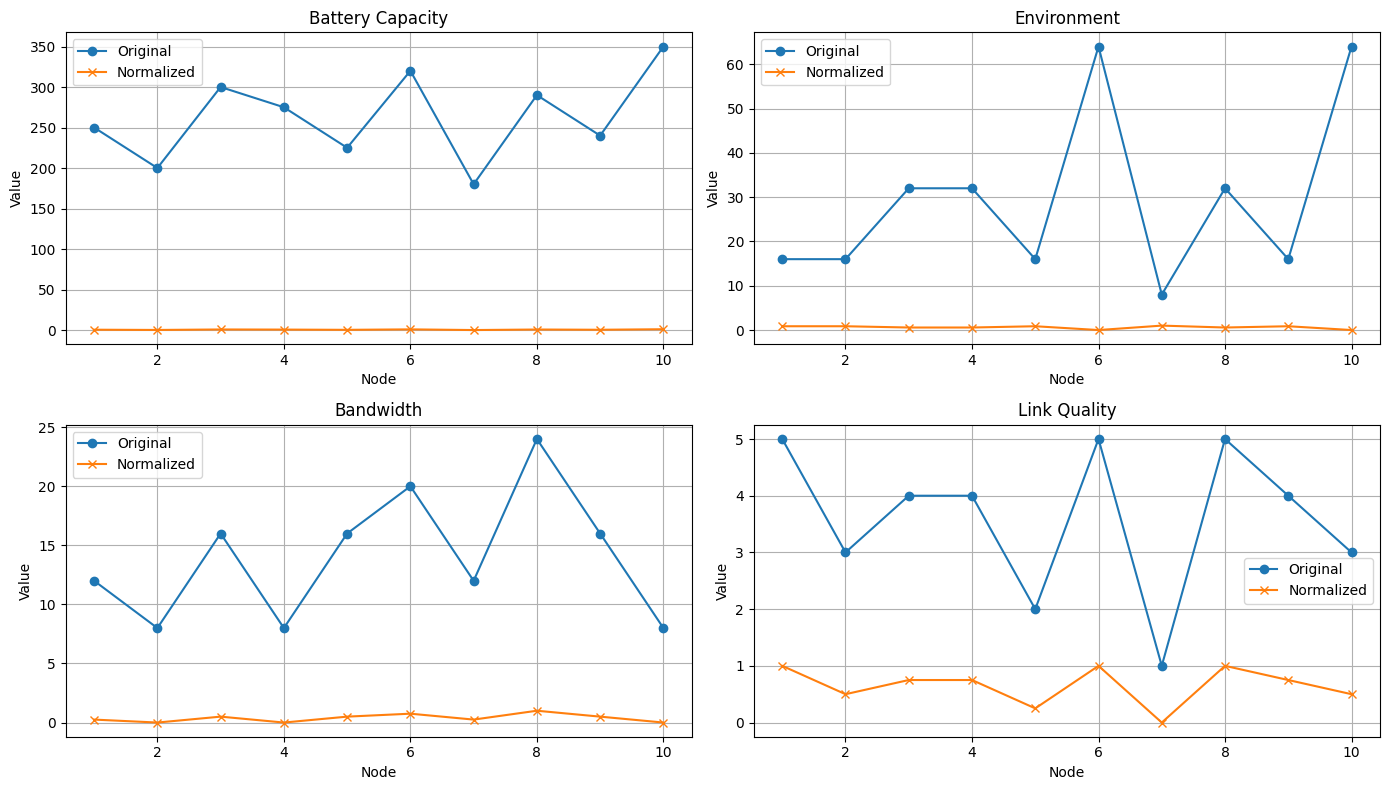

In [16]:
features = ['Battery Capacity', 'Environment', 'Bandwidth', 'Link Quality']
nodes = np.arange(1, 11)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
axs = axs.flatten()

for i in range(4):
    axs[i].plot(nodes, data[:, i], label='Original', marker='o')
    axs[i].plot(nodes, enh_norm[:, i], label='Normalized', marker='x')
    axs[i].set_title(features[i])
    axs[i].set_xlabel('Node')
    axs[i].set_ylabel('Value')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

In [17]:
weights_raw = np.array([25, 25, 25, 25], dtype=float)
weights = weights_raw / np.sum(weights_raw) 
weights

array([0.25, 0.25, 0.25, 0.25])

In [18]:
normalization_methods = {
    "Min-Max": min_max_normalization,
    "Vector": vector_normalization,
    "Logarithmic": log_normalization,
    "Enhanced Accuracy": enhanced_accuracy_normalization
}


In [19]:


def calculates_all(data, normalised_funcs, is_beneficial, csv_filename="results.csv"):
    results = {}

    all_records = []  # Store data for CSV

    for name, func in normalised_funcs.items():
        # Normalized data
        norm_data = func(data, is_beneficial)
        # Compute Weighted Normalized Vector
        weighted_normalized_data = norm_data * weights

        # Calculate Ideal Best (A+) and Ideal Worst (A-)
        ideal_best = []
        ideal_worst = []

        for j in range(weighted_normalized_data.shape[1]):
            if is_beneficial[j]:
                ideal_best.append(np.max(weighted_normalized_data[:, j]))
                ideal_worst.append(np.min(weighted_normalized_data[:, j]))
            else:
                ideal_best.append(np.min(weighted_normalized_data[:, j]))
                ideal_worst.append(np.max(weighted_normalized_data[:, j]))

        ideal_best = np.array(ideal_best)
        ideal_worst = np.array(ideal_worst)


        # Calculate Euclidean Distance to Ideal Best (S+) and Ideal Worst (S-)
        s_plus = np.sqrt(np.sum((weighted_normalized_data - ideal_best) ** 2, axis=1))
        s_minus = np.sqrt(np.sum((weighted_normalized_data - ideal_worst) ** 2, axis=1))

        # Calculate Performance Score (Closeness Coefficient)
        performance_score = s_minus / (s_plus + s_minus)

        # Get ranking order (descending by performance score)
        rank_order = np.argsort(-performance_score)
        top_alternatives = rank_order[:3]  # Top 3 alternatives

        # Store results for this normalization method
        results[name] = {
            'normalized_data': norm_data,
            'performance_scores': performance_score,
            'rank_order': rank_order,
            'top_alternatives': top_alternatives
        }

        # Append records to store in CSV
        for i, score in enumerate(performance_score):
            all_records.append({
                "Normalization_Method": name,
                "Alternative_Index": i,
                "Performance_Score": score,
                "Rank": np.where(rank_order == i)[0][0] + 1,  # Rank position
                "Top_Alternative": 1 if i in top_alternatives else 0
            })

    # Convert records to DataFrame and save to CSV
    df = pd.DataFrame(all_records)
    df.to_csv(csv_filename, mode='a', index=False, header=not pd.io.common.file_exists(csv_filename))

    return results


In [20]:
results = calculates_all(data, normalization_methods, is_beneficial)

for method, result in results.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value+1}")



Normalization method: Min-Max
normalized_data: [[1.41176471 1.85714286 1.25       2.        ]
 [1.11764706 1.85714286 1.         1.5       ]
 [1.70588235 1.57142857 1.5        1.75      ]
 [1.55882353 1.57142857 1.         1.75      ]
 [1.26470588 1.85714286 1.5        1.25      ]
 [1.82352941 1.         1.75       2.        ]
 [1.         2.         1.25       1.        ]
 [1.64705882 1.57142857 2.         2.        ]
 [1.35294118 1.85714286 1.5        1.75      ]
 [2.         1.         1.         1.5       ]]
performance_scores: [1.46610878 1.2428432  1.58935493 1.44980331 1.30523214 1.85471039
 1.11696133 1.70604335 1.44696153 1.57294902]
rank_order: [ 6  8  3 10  1  4  9  5  2  7]
top_alternatives: [6 8 3]

Normalization method: Vector
normalized_data: [[1.29508926 1.85603685 1.25445668 1.41380294]
 [1.23607141 1.85603685 1.16963779 1.24828177]
 [1.35410712 1.7120737  1.33927557 1.33104236]
 [1.32459819 1.7120737  1.16963779 1.33104236]
 [1.26558034 1.85603685 1.33927557 1.165521

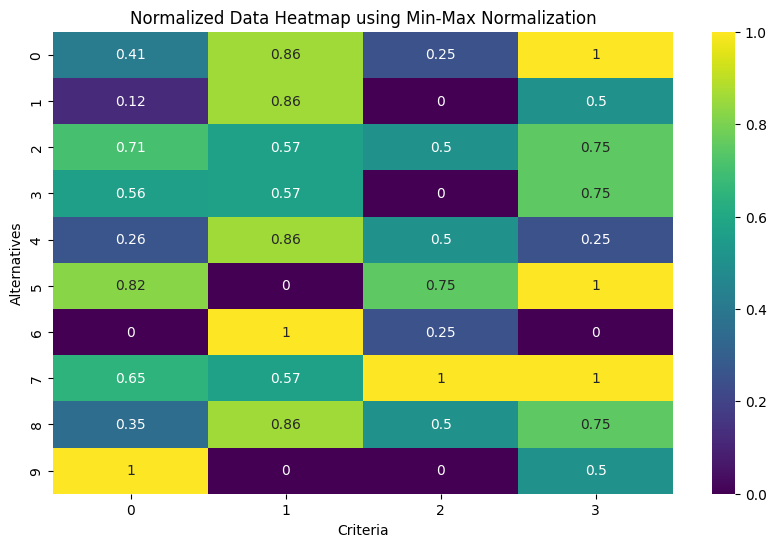

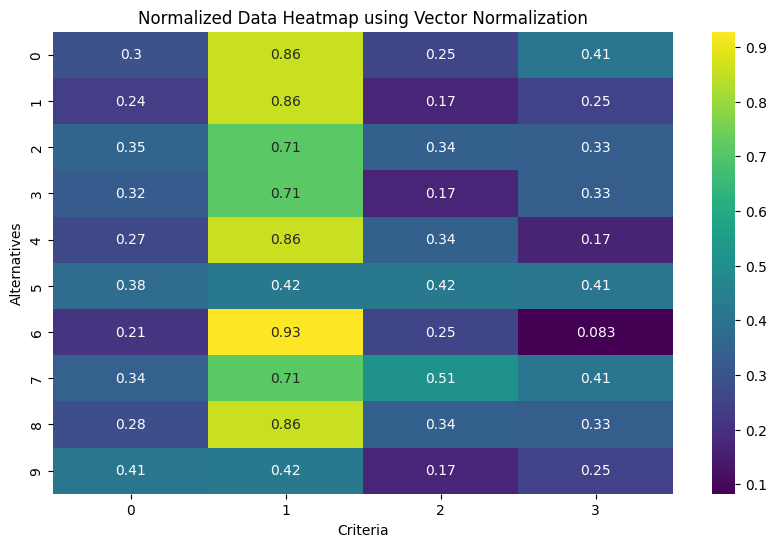

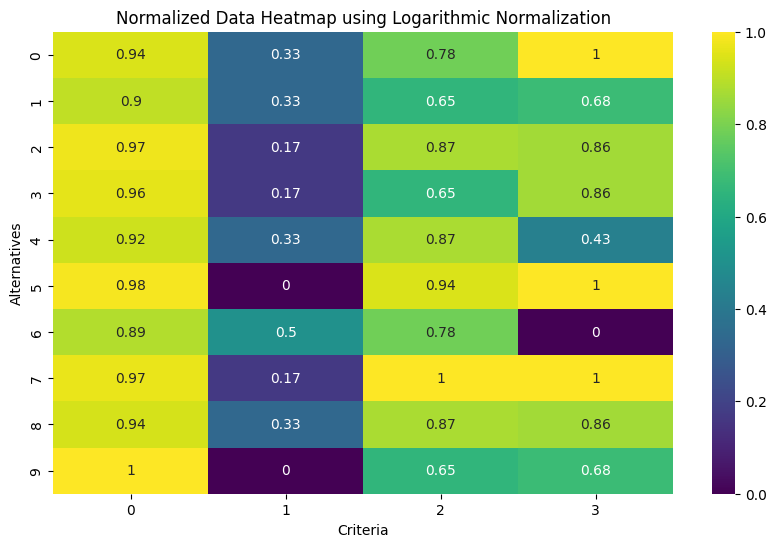

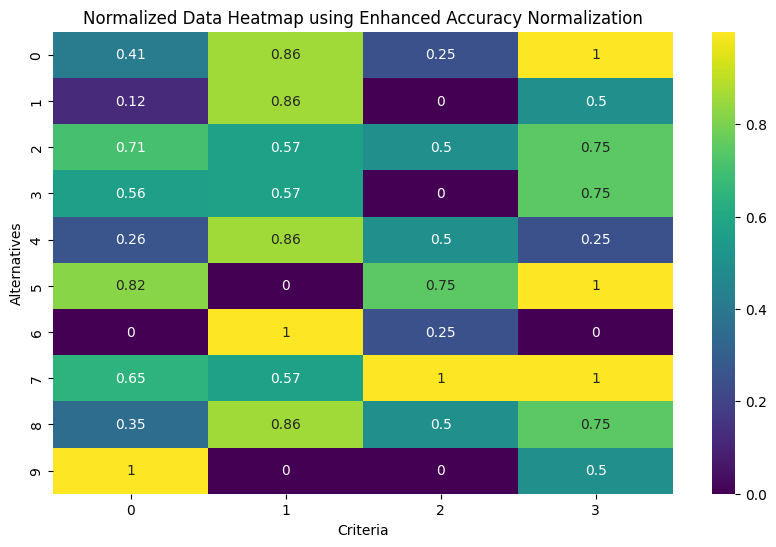

In [21]:
import seaborn as sns

for method, result in results.items():
    norm_data = result['normalized_data']
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(norm_data, annot=True, cmap='viridis', cbar=True)
    plt.xlabel('Criteria')
    plt.ylabel('Alternatives')
    plt.title(f'Normalized Data Heatmap using {method} Normalization')
    plt.show()


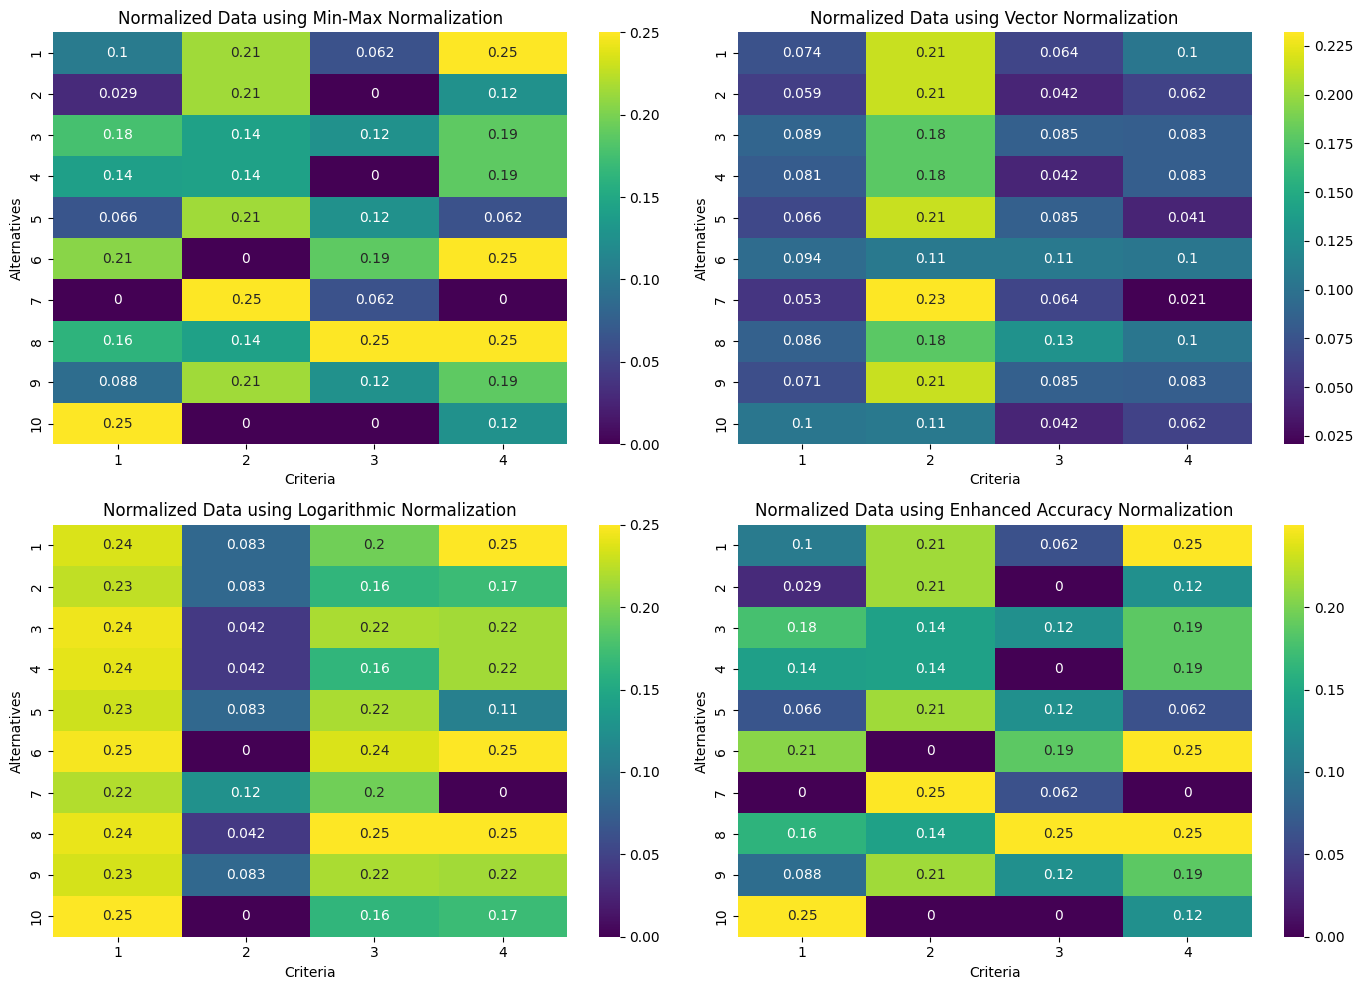

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Number of methods
n_methods = len(results)
cols = 2  # Adjust columns as needed
rows = (n_methods + cols - 1) // cols  # Compute rows to fit all plots

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()  # Flatten for easy iteration

for idx, (method, result) in enumerate(results.items()):
    norm_data = result['normalized_data']*weights
    
    # Update alternative labels to start from 1
    alt_labels = [f"{i+1}" for i in range(norm_data.shape[0])]
    crit_labels = [f"{j+1}" for j in range(norm_data.shape[1])]

    sns.heatmap(
        norm_data,
        annot=True,
        cmap='viridis',
        cbar=True,
        ax=axes[idx],
        xticklabels=crit_labels,
        yticklabels=alt_labels
    )
    axes[idx].set_xlabel('Criteria')
    axes[idx].set_ylabel('Alternatives')
    axes[idx].set_title(f'Normalized Data using {method} Normalization')

# Turn off any unused subplots
for ax in axes[n_methods:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


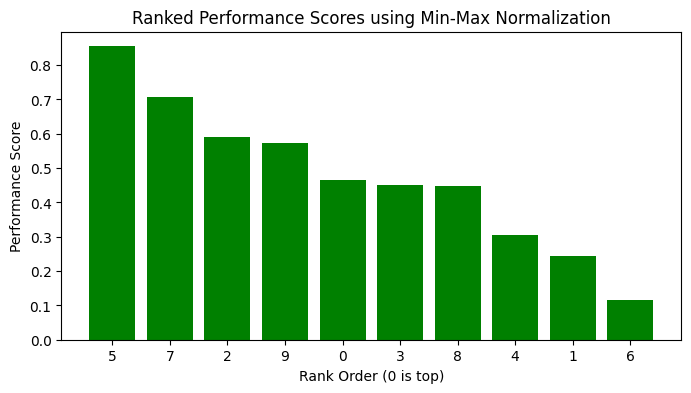

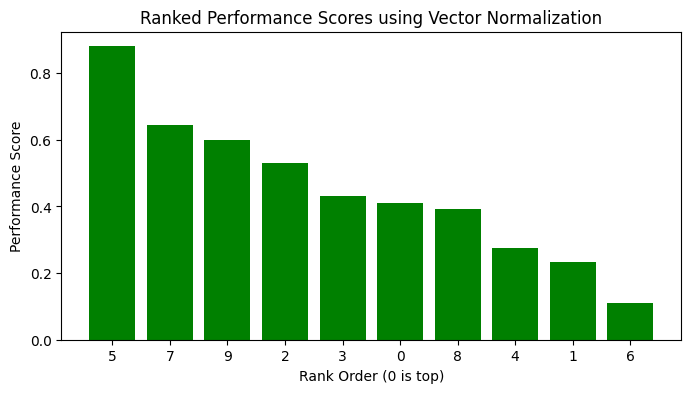

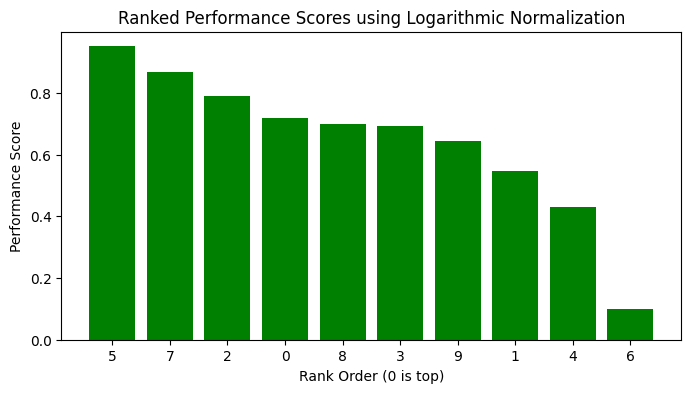

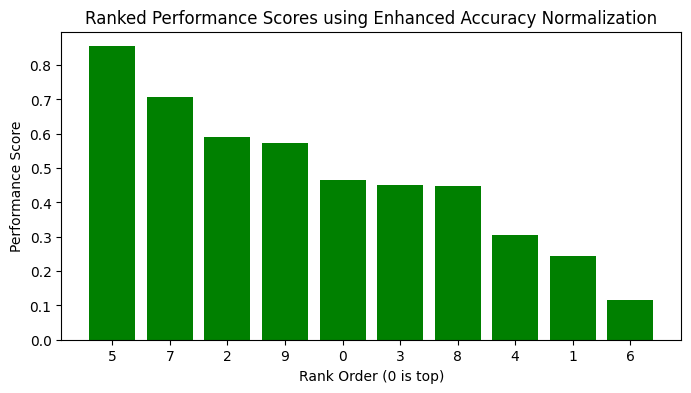

In [23]:
for method, result in results.items():
    rank_order = result['rank_order']
    performance_scores = result['performance_scores'][rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(rank_order)), performance_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization')
    plt.xticks(range(len(rank_order)), rank_order)  # Label bars with the alternative indices
    plt.show()


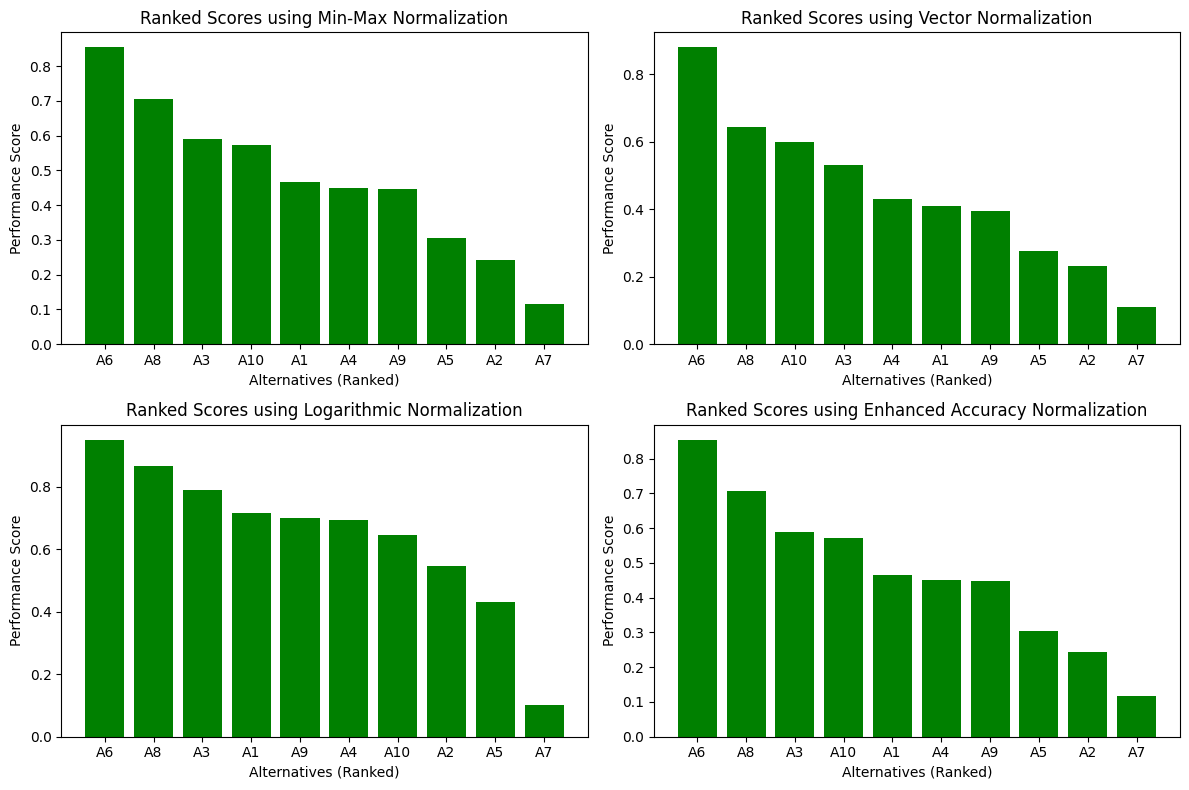

In [24]:
import matplotlib.pyplot as plt

# Determine grid size
n_methods = len(results)
cols = 2
rows = (n_methods + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for idx, (method, result) in enumerate(results.items()):
    rank_order = result['rank_order']
    performance_scores = result['performance_scores'][rank_order]

    # Convert 0-based alternative indices to 1-based labels
    alt_labels = [f"A{i+1}" for i in rank_order]

    axes[idx].bar(range(len(rank_order)), performance_scores, color='green')
    axes[idx].set_xlabel('Alternatives (Ranked)')
    axes[idx].set_ylabel('Performance Score')
    axes[idx].set_title(f'Ranked Scores using {method} Normalization')
    axes[idx].set_xticks(range(len(rank_order)))
    axes[idx].set_xticklabels(alt_labels)

# Turn off unused subplots
for ax in axes[n_methods:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


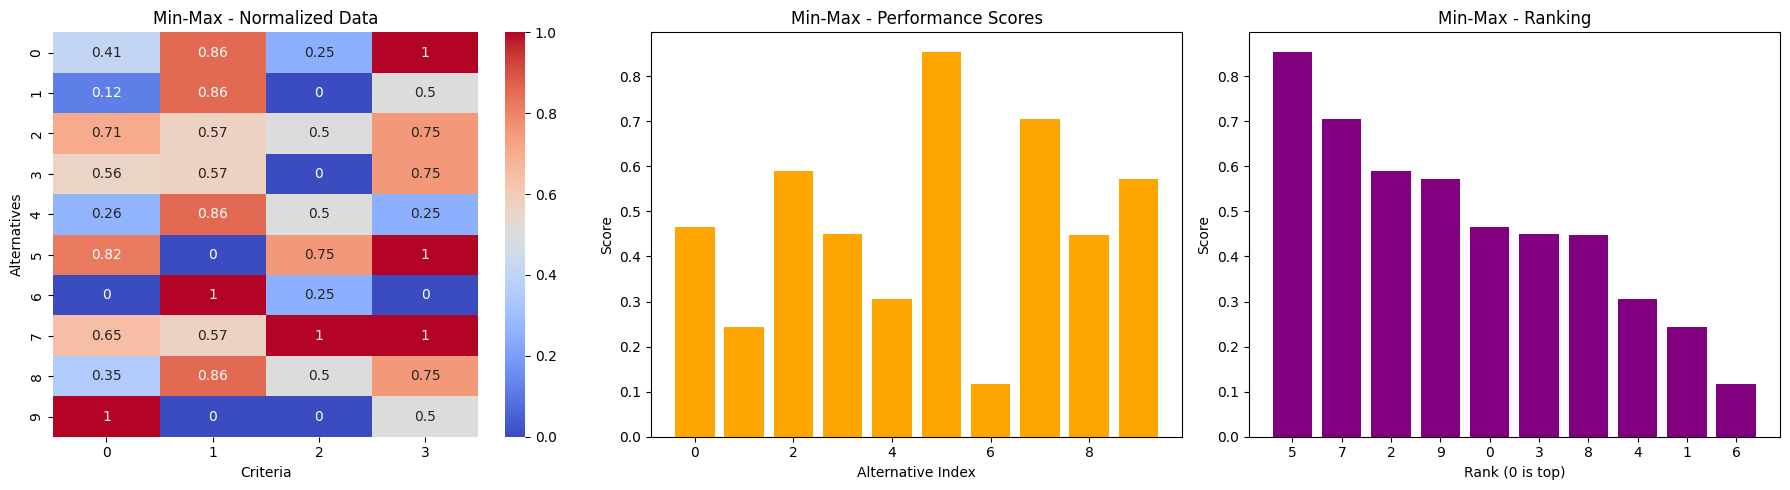

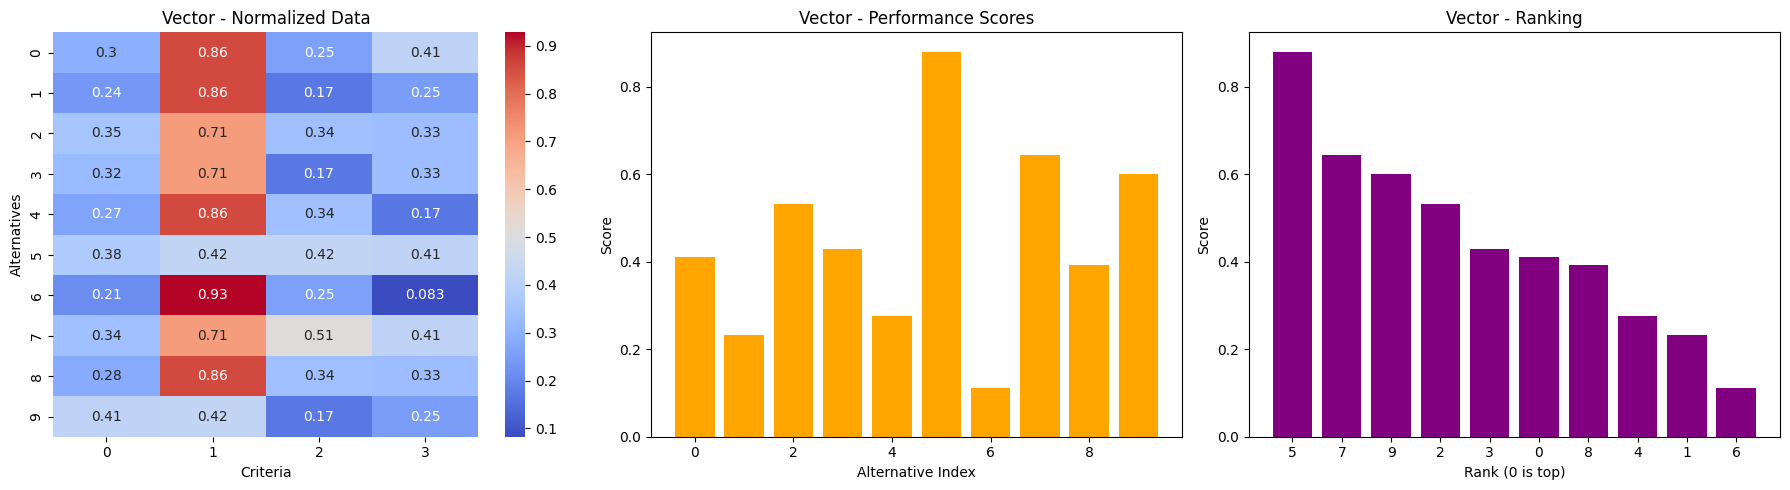

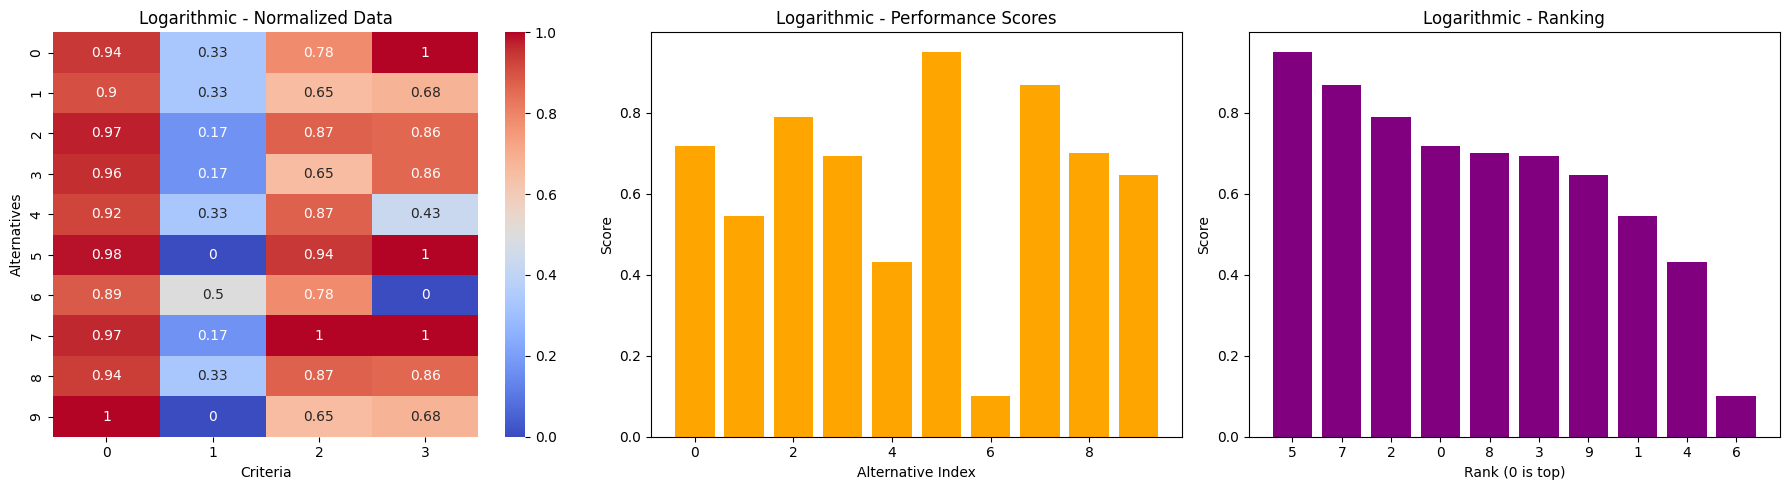

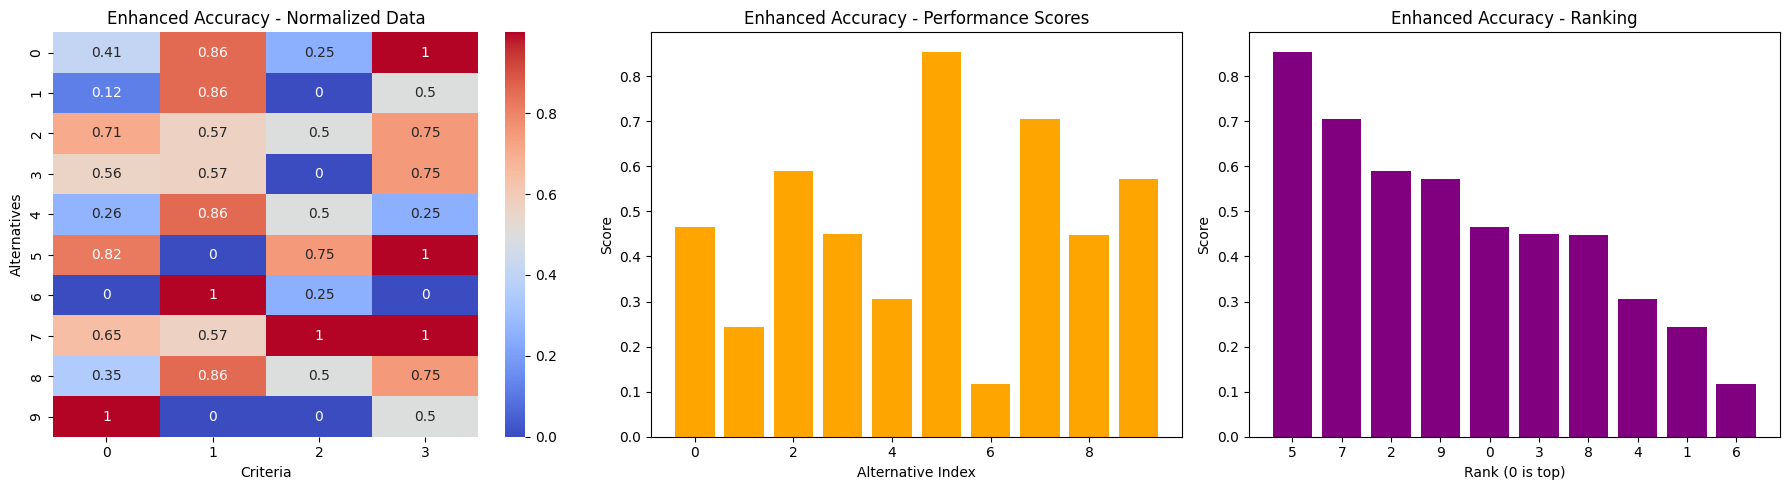

In [25]:
for method, result in results.items():
    norm_data = result['normalized_data']
    performance_scores = result['performance_scores']
    rank_order = result['rank_order']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Heatmap for normalized data
    sns.heatmap(norm_data, ax=axes[0], annot=True, cmap='coolwarm')
    axes[0].set_title(f'{method} - Normalized Data')
    axes[0].set_xlabel('Criteria')
    axes[0].set_ylabel('Alternatives')
    
    # Bar chart for performance scores
    axes[1].bar(range(len(performance_scores)), performance_scores, color='orange')
    axes[1].set_title(f'{method} - Performance Scores')
    axes[1].set_xlabel('Alternative Index')
    axes[1].set_ylabel('Score')
    
    # Bar chart for ranking order
    axes[2].bar(range(len(rank_order)), performance_scores[rank_order], color='purple')
    axes[2].set_title(f'{method} - Ranking')
    axes[2].set_xlabel('Rank (0 is top)')
    axes[2].set_ylabel('Score')
    axes[2].set_xticks(range(len(rank_order)))
    axes[2].set_xticklabels(rank_order)
    
    plt.tight_layout()
    plt.show()


Node == 20


In [26]:
raw_da = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"]            # Node 20
]


Encoding

In [27]:
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}
# Convert to numeric, especially for the "Looks" column
encoded_da = []
for row in raw_da:
    battery_capacity    = row[0]
    environmental  = row[1]
    bandwidth   = row[2]
    link_quality   = looks_mapping[row[3]]  # Convert text to numeric
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

da = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix:\n", da)

Encoded Data Matrix:
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]]


In [28]:
min_max_norm_20 = min_max_normalization(da, is_beneficial)
vector_norm_20 = vector_normalization(da, is_beneficial)
log_norm_20 = log_normalization(da, is_beneficial)
enh_norm_20 = enhanced_accuracy_normalization(da, is_beneficial)

print("Min-Max Normalization:")
print(min_max_norm_20)
print("\nVector Normalization:")
print(vector_norm_20)
print("\nLogarithmic Normalization:")
print(log_norm_20)
print("\nEnhanced Accuracy Normalization:")
print(enh_norm_20)


Min-Max Normalization:
[[0.38888889 0.85714286 0.25       1.        ]
 [0.11111111 0.85714286 0.         0.5       ]
 [0.66666667 0.57142857 0.5        0.75      ]
 [0.52777778 0.57142857 0.         0.75      ]
 [0.25       0.85714286 0.5        0.25      ]
 [0.77777778 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.61111111 0.57142857 1.         1.        ]
 [0.33333333 0.85714286 0.5        0.75      ]
 [0.94444444 0.         0.         0.5       ]
 [0.44444444 0.85714286 0.25       0.75      ]
 [0.16666667 1.         0.         0.25      ]
 [0.83333333 0.57142857 0.75       1.        ]
 [0.52777778 0.85714286 0.5        0.5       ]
 [0.72222222 0.57142857 1.         0.75      ]
 [0.08333333 1.         0.25       0.        ]
 [0.58333333 0.85714286 0.5        0.75      ]
 [1.         0.         0.75       1.        ]
 [0.27777778 0.85714286 0.         0.25      ]
 [0.72222222 0.57142857 0.25       0.75      ]]

Vector Normalization:
[[0.20358704 

In [29]:
# import seaborn as sns

# for method, result in results.items():
#     norm_data = result['normalized_data']
    
#     plt.figure(figsize=(10, 6))
#     sns.heatmap(norm_data, annot=True, cmap='viridis', cbar=True)
#     plt.xlabel('Criteria')
#     plt.ylabel('Alternatives')
#     plt.title(f'Normalized Data Heatmap using {method} Normalization')
#     plt.show()


In [30]:
results_20 = calculates_all(da, normalization_methods, is_beneficial)

for method, result in results_20.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.38888889 0.85714286 0.25       1.        ]
 [0.11111111 0.85714286 0.         0.5       ]
 [0.66666667 0.57142857 0.5        0.75      ]
 [0.52777778 0.57142857 0.         0.75      ]
 [0.25       0.85714286 0.5        0.25      ]
 [0.77777778 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.61111111 0.57142857 1.         1.        ]
 [0.33333333 0.85714286 0.5        0.75      ]
 [0.94444444 0.         0.         0.5       ]
 [0.44444444 0.85714286 0.25       0.75      ]
 [0.16666667 1.         0.         0.25      ]
 [0.83333333 0.57142857 0.75       1.        ]
 [0.52777778 0.85714286 0.5        0.5       ]
 [0.72222222 0.57142857 1.         0.75      ]
 [0.08333333 1.         0.25       0.        ]
 [0.58333333 0.85714286 0.5        0.75      ]
 [1.         0.         0.75       1.        ]
 [0.27777778 0.85714286 0.         0.25      ]
 [0.72222222 0.57142857 0.25       0.75      ]]
performance

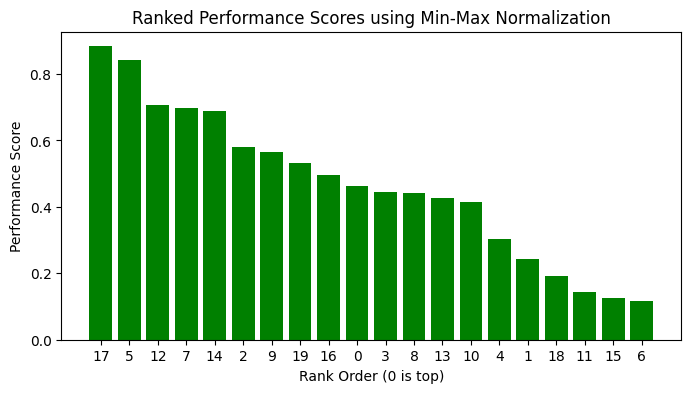

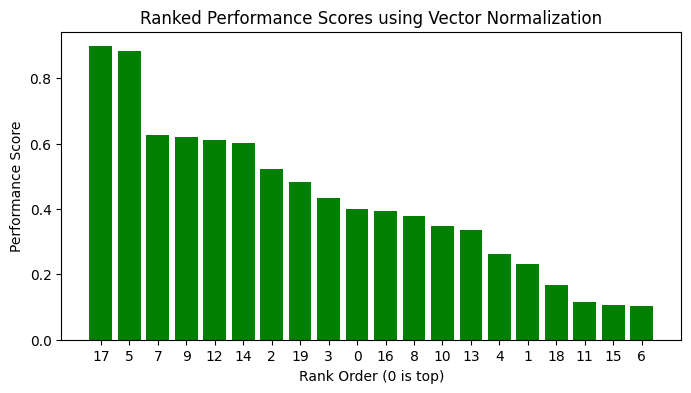

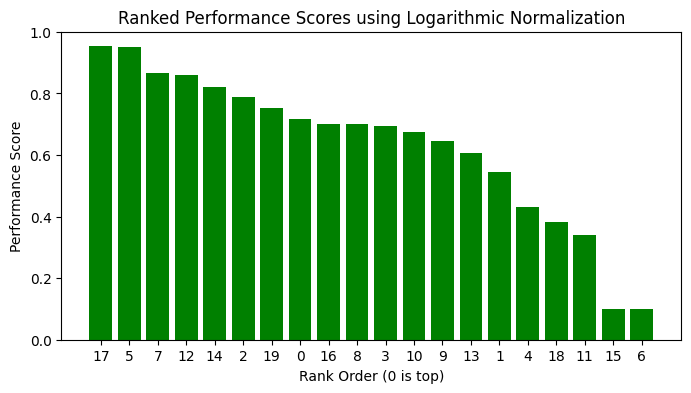

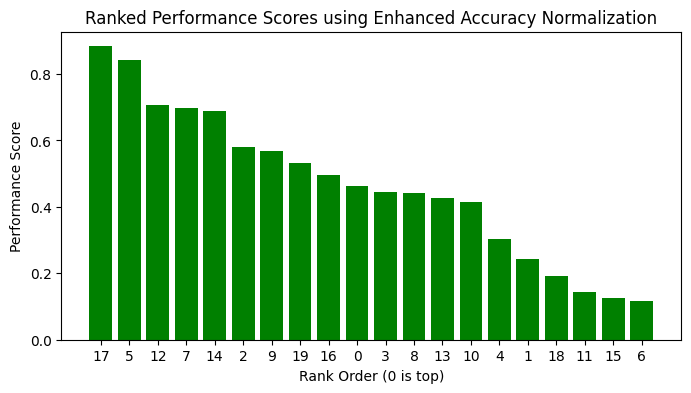

In [31]:
for method, result in results_20.items():
    rank_order = result['rank_order']
    performance_scores = result['performance_scores'][rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(rank_order)), performance_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization')
    plt.xticks(range(len(rank_order)), rank_order)  # Label bars with the alternative indices
    plt.show()


Nodes == 30 

In [32]:
import numpy as np

raw_da_30 = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"],           # Node 20
    [320, 32, 16, "Excellent"],      # Node 21
    [215, 16, 8, "Average"],         # Node 22
    [305, 32, 12, "Good"],           # Node 23
    [265, 16, 16, "Good"],           # Node 24
    [230, 8, 8, "Below Average"],    # Node 25
    [330, 64, 20, "Excellent"],      # Node 26
    [190, 8, 12, "Poor"],            # Node 27
    [300, 32, 24, "Excellent"],      # Node 28
    [245, 16, 16, "Good"],           # Node 29
    [355, 64, 8, "Average"]          # Node 30
]

looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}

# Initialize a new list for encoded data.
encoded_da = []  # Make sure this list is empty!

for row in raw_da_30:
    battery_capacity = row[0]
    environmental = row[1]
    bandwidth = row[2]
    link_quality = looks_mapping[row[3]]  # Convert text to numeric
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

# Convert the encoded list to a NumPy array
da_30 = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix:\n", da_30)
print("Shape of data matrix:", da_30.shape)


Encoded Data Matrix:
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]
 [320.  32.  16.   5.]
 [215.  16.   8.   3.]
 [305.  32.  12.   4.]
 [265.  16.  16.   4.]
 [230.   8.   8.   2.]
 [330.  64.  20.   5.]
 [190.   8.  12.   1.]
 [300.  32.  24.   5.]
 [245.  16.  16.   4.]
 [355.  64.   8.   3.]]
Shape of data matrix: (30, 4)


In [33]:
results_30 = calculates_all(da_30, normalization_methods, is_beneficial)

for method, result in results_30.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.38888889 0.85714286 0.25       1.        ]
 [0.11111111 0.85714286 0.         0.5       ]
 [0.66666667 0.57142857 0.5        0.75      ]
 [0.52777778 0.57142857 0.         0.75      ]
 [0.25       0.85714286 0.5        0.25      ]
 [0.77777778 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.61111111 0.57142857 1.         1.        ]
 [0.33333333 0.85714286 0.5        0.75      ]
 [0.94444444 0.         0.         0.5       ]
 [0.44444444 0.85714286 0.25       0.75      ]
 [0.16666667 1.         0.         0.25      ]
 [0.83333333 0.57142857 0.75       1.        ]
 [0.52777778 0.85714286 0.5        0.5       ]
 [0.72222222 0.57142857 1.         0.75      ]
 [0.08333333 1.         0.25       0.        ]
 [0.58333333 0.85714286 0.5        0.75      ]
 [1.         0.         0.75       1.        ]
 [0.27777778 0.85714286 0.         0.25      ]
 [0.72222222 0.57142857 0.25       0.75      ]
 [0.77777778

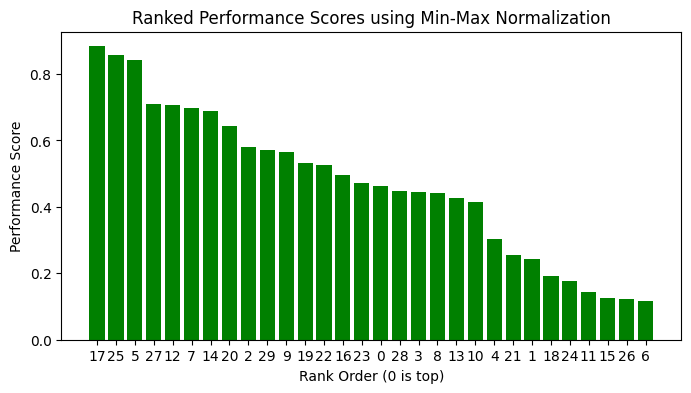

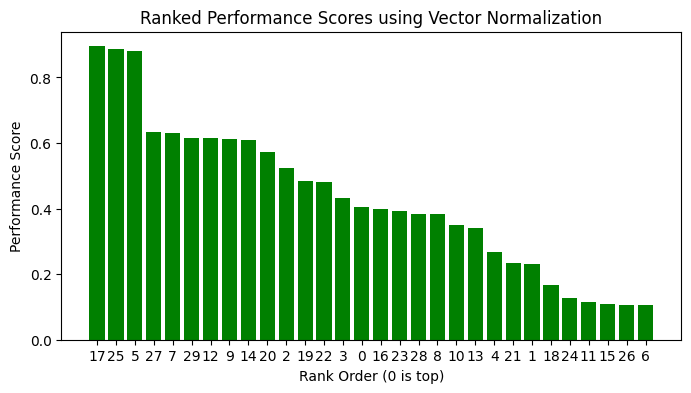

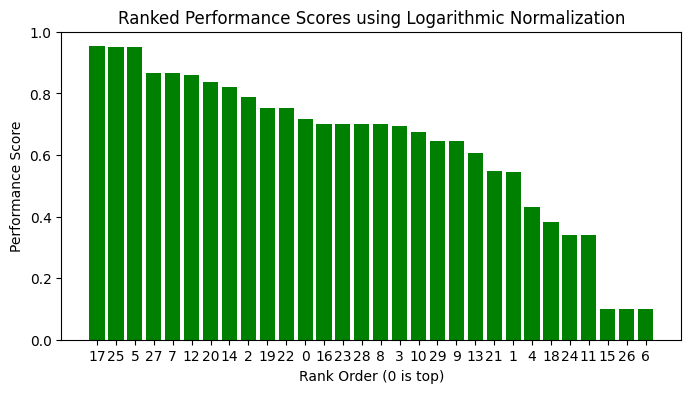

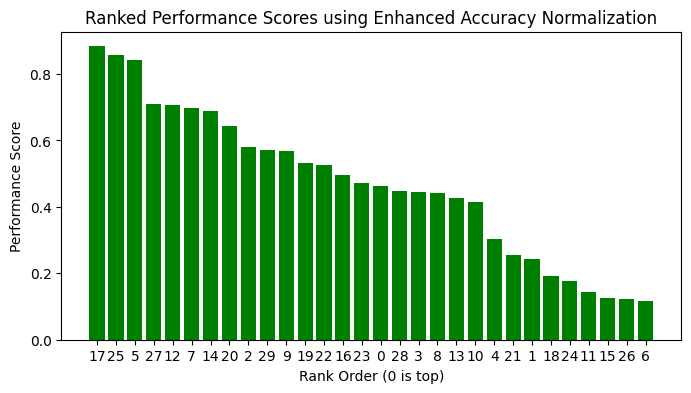

In [34]:
for method, result in results_30.items():
    rank_order = result['rank_order']
    performance_scores = result['performance_scores'][rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(rank_order)), performance_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization')
    plt.xticks(range(len(rank_order)), rank_order)  # Label bars with the alternative indices
    plt.show()


Node == 40

In [35]:
import numpy as np

# Original 30 data points
raw_da_40 = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"],           # Node 20
    [320, 32, 16, "Excellent"],      # Node 21
    [215, 16, 8, "Average"],         # Node 22
    [305, 32, 12, "Good"],           # Node 23
    [265, 16, 16, "Good"],           # Node 24
    [230, 8, 8, "Below Average"],    # Node 25
    [330, 64, 20, "Excellent"],      # Node 26
    [190, 8, 12, "Poor"],            # Node 27
    [300, 32, 24, "Excellent"],      # Node 28
    [245, 16, 16, "Good"],           # Node 29
    [355, 64, 8, "Average"],         # Node 30
    # Fabricated 10 new nodes (Node 31 to Node 40)
    [265, 16, 10, "Good"],           # Node 31
    [240, 8, 8, "Below Average"],    # Node 32
    [340, 32, 18, "Excellent"],      # Node 33
    [280, 16, 14, "Average"],        # Node 34
    [310, 32, 20, "Good"],           # Node 35
    [205, 16, 10, "Poor"],           # Node 36
    [295, 32, 16, "Excellent"],      # Node 37
    [225, 8, 12, "Below Average"],   # Node 38
    [315, 32, 14, "Good"],           # Node 39
    [355, 64, 10, "Excellent"]       # Node 40
]

# Mapping for the text values in the "Looks" column
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}

# Encode the data into numeric format
encoded_da = []  # Ensure starting with an empty list

for row in raw_da_40:
    battery_capacity = row[0]
    environmental = row[1]
    bandwidth = row[2]
    link_quality = looks_mapping[row[3]]  # Convert text to numeric value
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

# Convert the encoded list to a NumPy array
da_40 = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix:\n", da_40)
print("Shape of data matrix:", da_40.shape)


Encoded Data Matrix:
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]
 [320.  32.  16.   5.]
 [215.  16.   8.   3.]
 [305.  32.  12.   4.]
 [265.  16.  16.   4.]
 [230.   8.   8.   2.]
 [330.  64.  20.   5.]
 [190.   8.  12.   1.]
 [300.  32.  24.   5.]
 [245.  16.  16.   4.]
 [355.  64.   8.   3.]
 [265.  16.  10.   4.]
 [240.   8.   8.   2.]
 [340.  32.  18.   5.]
 [280.  16.  14.   3.]
 [310.  32.  20.   4.]
 [205.  16.  10.   1.]
 [295.  32.  16.   5.]
 [225.   8.  12.   2.]
 [315.  32.  14.   4.]
 [355.  64.  10.   5.]]
Shape of data matrix: (40, 4)


In [36]:
results_40 = calculates_all(da_40, normalization_methods, is_beneficial)

for method, result in results_40.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.38888889 0.85714286 0.25       1.        ]
 [0.11111111 0.85714286 0.         0.5       ]
 [0.66666667 0.57142857 0.5        0.75      ]
 [0.52777778 0.57142857 0.         0.75      ]
 [0.25       0.85714286 0.5        0.25      ]
 [0.77777778 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.61111111 0.57142857 1.         1.        ]
 [0.33333333 0.85714286 0.5        0.75      ]
 [0.94444444 0.         0.         0.5       ]
 [0.44444444 0.85714286 0.25       0.75      ]
 [0.16666667 1.         0.         0.25      ]
 [0.83333333 0.57142857 0.75       1.        ]
 [0.52777778 0.85714286 0.5        0.5       ]
 [0.72222222 0.57142857 1.         0.75      ]
 [0.08333333 1.         0.25       0.        ]
 [0.58333333 0.85714286 0.5        0.75      ]
 [1.         0.         0.75       1.        ]
 [0.27777778 0.85714286 0.         0.25      ]
 [0.72222222 0.57142857 0.25       0.75      ]
 [0.77777778

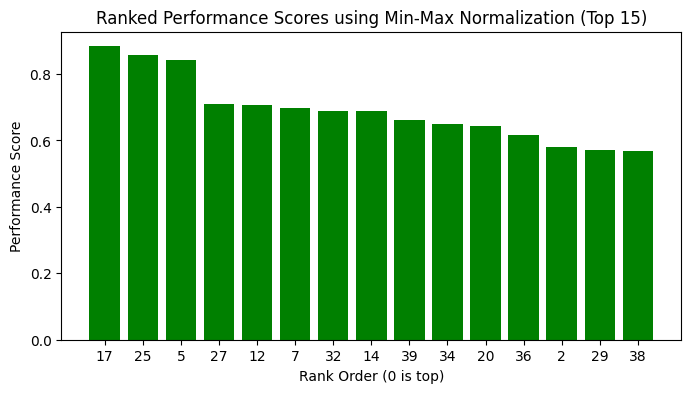

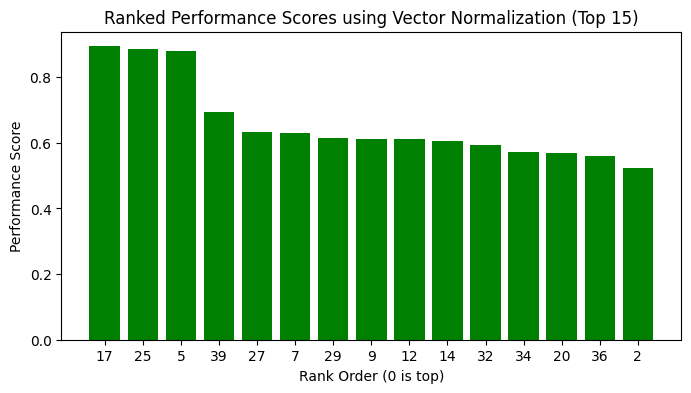

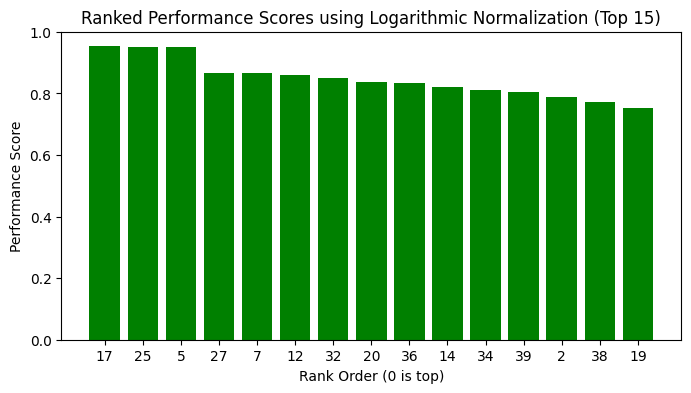

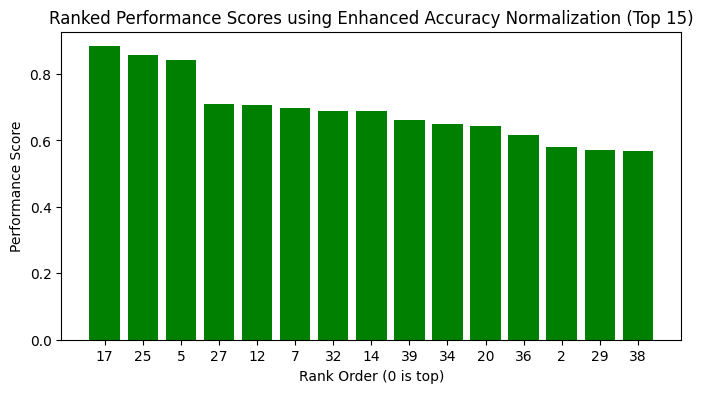

In [37]:
for method, result in results_40.items():
    # Get the ranking order of alternatives
    rank_order = result['rank_order']
    # Slice only the top 15 entries
    top15_rank_order = rank_order[:15]
    top15_scores = result['performance_scores'][top15_rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(top15_rank_order)), top15_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization (Top 15)')
    plt.xticks(range(len(top15_rank_order)), top15_rank_order)  # Label bars with the alternative indices
    plt.show()


Node == 50

In [38]:
import numpy as np

# Original 40 data points from previous fabrication
raw_da_40 = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"],           # Node 20
    [320, 32, 16, "Excellent"],      # Node 21
    [215, 16, 8, "Average"],         # Node 22
    [305, 32, 12, "Good"],           # Node 23
    [265, 16, 16, "Good"],           # Node 24
    [230, 8, 8, "Below Average"],    # Node 25
    [330, 64, 20, "Excellent"],      # Node 26
    [190, 8, 12, "Poor"],            # Node 27
    [300, 32, 24, "Excellent"],      # Node 28
    [245, 16, 16, "Good"],           # Node 29
    [355, 64, 8, "Average"],         # Node 30
    [265, 16, 10, "Good"],           # Node 31
    [240, 8, 8, "Below Average"],    # Node 32
    [340, 32, 18, "Excellent"],      # Node 33
    [280, 16, 14, "Average"],        # Node 34
    [310, 32, 20, "Good"],           # Node 35
    [205, 16, 10, "Poor"],           # Node 36
    [295, 32, 16, "Excellent"],      # Node 37
    [225, 8, 12, "Below Average"],   # Node 38
    [315, 32, 14, "Good"],           # Node 39
    [355, 64, 10, "Excellent"]       # Node 40
]

# Fabricated 10 new nodes (Node 41 to Node 50)
fabricated_nodes = [
    [265, 16, 12, "Good"],           # Node 41
    [205, 8, 10, "Below Average"],   # Node 42
    [345, 32, 18, "Excellent"],      # Node 43
    [280, 16, 12, "Average"],        # Node 44
    [315, 32, 22, "Good"],           # Node 45
    [210, 16, 14, "Poor"],           # Node 46
    [295, 32, 16, "Excellent"],      # Node 47
    [230, 8, 12, "Below Average"],   # Node 48
    [320, 32, 14, "Good"],           # Node 49
    [360, 64, 10, "Excellent"]       # Node 50
]

# Create the complete data by extending the original 40 nodes with the 10 fabricated nodes
raw_da_50 = raw_da_40.copy()  # Ensure previous data remains intact
raw_da_50.extend(fabricated_nodes)

# Mapping for the "Looks" column from text to numeric values
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}

# Encode the data into numeric format
encoded_da = []  # Start with an empty list
for row in raw_da_50:
    battery_capacity = row[0]
    environmental = row[1]
    bandwidth = row[2]
    link_quality = looks_mapping[row[3]]  # Convert the qualitative "Looks" to a numeric value
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

# Convert the encoded list to a NumPy array
da_50 = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix (50 nodes):\n", da_50)
print("Shape of data matrix:", da_50.shape)


Encoded Data Matrix (50 nodes):
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]
 [320.  32.  16.   5.]
 [215.  16.   8.   3.]
 [305.  32.  12.   4.]
 [265.  16.  16.   4.]
 [230.   8.   8.   2.]
 [330.  64.  20.   5.]
 [190.   8.  12.   1.]
 [300.  32.  24.   5.]
 [245.  16.  16.   4.]
 [355.  64.   8.   3.]
 [265.  16.  10.   4.]
 [240.   8.   8.   2.]
 [340.  32.  18.   5.]
 [280.  16.  14.   3.]
 [310.  32.  20.   4.]
 [205.  16.  10.   1.]
 [295.  32.  16.   5.]
 [225.   8.  12.   2.]
 [315.  32.  14.   4.]
 [355.  64.  10.   5.]
 [265.  16.  12.   4.]
 [205.   8.  10.   2.]
 

In [39]:
results_50 = calculates_all(da_50, normalization_methods, is_beneficial)

for method, result in results_50.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.38888889 0.85714286 0.25       1.        ]
 [0.11111111 0.85714286 0.         0.5       ]
 [0.66666667 0.57142857 0.5        0.75      ]
 [0.52777778 0.57142857 0.         0.75      ]
 [0.25       0.85714286 0.5        0.25      ]
 [0.77777778 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.61111111 0.57142857 1.         1.        ]
 [0.33333333 0.85714286 0.5        0.75      ]
 [0.94444444 0.         0.         0.5       ]
 [0.44444444 0.85714286 0.25       0.75      ]
 [0.16666667 1.         0.         0.25      ]
 [0.83333333 0.57142857 0.75       1.        ]
 [0.52777778 0.85714286 0.5        0.5       ]
 [0.72222222 0.57142857 1.         0.75      ]
 [0.08333333 1.         0.25       0.        ]
 [0.58333333 0.85714286 0.5        0.75      ]
 [1.         0.         0.75       1.        ]
 [0.27777778 0.85714286 0.         0.25      ]
 [0.72222222 0.57142857 0.25       0.75      ]
 [0.77777778

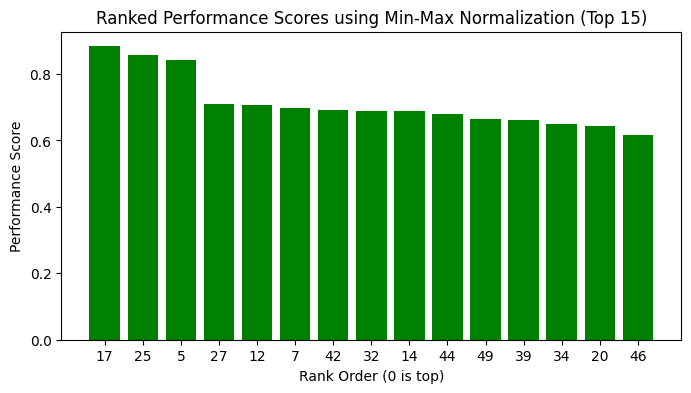

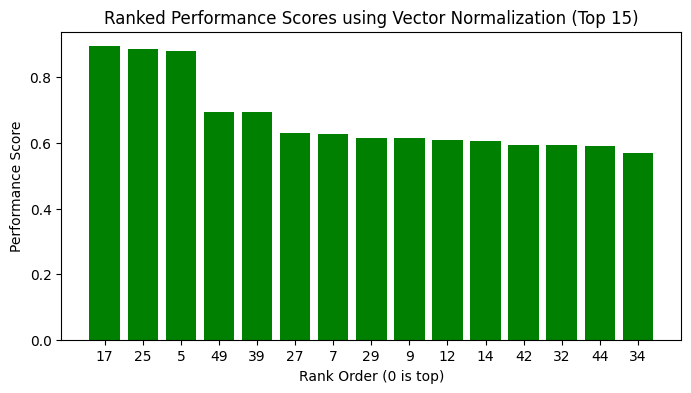

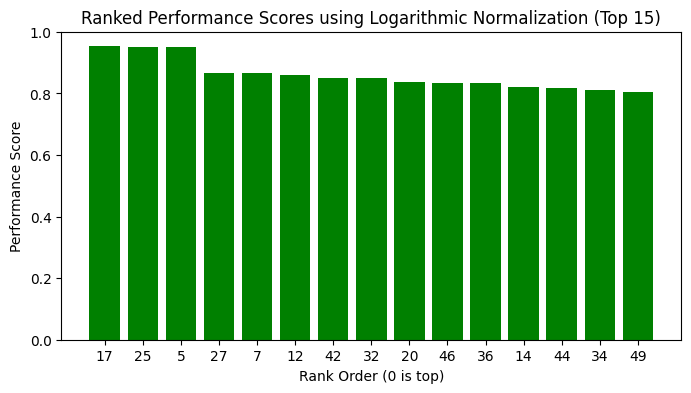

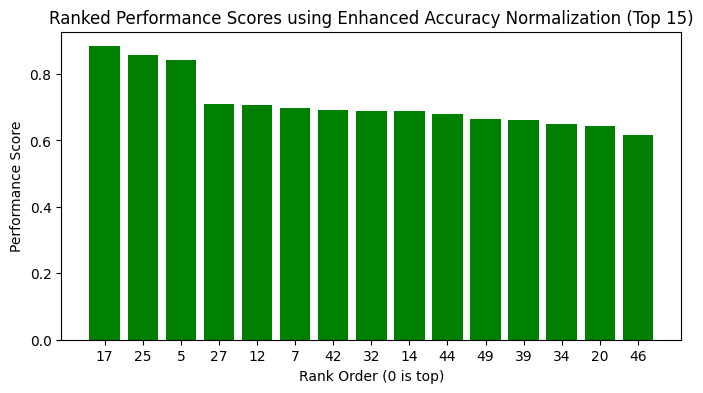

In [40]:
for method, result in results_50.items():
    # Get the ranking order of alternatives
    rank_order = result['rank_order']
    # Slice only the top 15 entries
    top15_rank_order = rank_order[:15]
    top15_scores = result['performance_scores'][top15_rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(top15_rank_order)), top15_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization (Top 15)')
    plt.xticks(range(len(top15_rank_order)), top15_rank_order)  # Label bars with the alternative indices
    plt.show()


NOde == 70 


In [41]:
import numpy as np

# Original 40 data points from previous fabrication
raw_da_40 = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"],           # Node 20
    [320, 32, 16, "Excellent"],      # Node 21
    [215, 16, 8, "Average"],         # Node 22
    [305, 32, 12, "Good"],           # Node 23
    [265, 16, 16, "Good"],           # Node 24
    [230, 8, 8, "Below Average"],    # Node 25
    [330, 64, 20, "Excellent"],      # Node 26
    [190, 8, 12, "Poor"],            # Node 27
    [300, 32, 24, "Excellent"],      # Node 28
    [245, 16, 16, "Good"],           # Node 29
    [355, 64, 8, "Average"],         # Node 30
    [265, 16, 10, "Good"],           # Node 31
    [240, 8, 8, "Below Average"],    # Node 32
    [340, 32, 18, "Excellent"],      # Node 33
    [280, 16, 14, "Average"],        # Node 34
    [310, 32, 20, "Good"],           # Node 35
    [205, 16, 10, "Poor"],           # Node 36
    [295, 32, 16, "Excellent"],      # Node 37
    [225, 8, 12, "Below Average"],   # Node 38
    [315, 32, 14, "Good"],           # Node 39
    [355, 64, 10, "Excellent"]       # Node 40
]

# Fabricated 10 new nodes (Node 41 to Node 50)
fabricated_nodes_50 = [
    [265, 16, 12, "Good"],           # Node 41
    [205, 8, 10, "Below Average"],   # Node 42
    [345, 32, 18, "Excellent"],      # Node 43
    [280, 16, 12, "Average"],        # Node 44
    [315, 32, 22, "Good"],           # Node 45
    [210, 16, 14, "Poor"],           # Node 46
    [295, 32, 16, "Excellent"],      # Node 47
    [230, 8, 12, "Below Average"],   # Node 48
    [320, 32, 14, "Good"],           # Node 49
    [360, 64, 10, "Excellent"]       # Node 50
]

# Combine to form the complete data for 50 nodes
raw_da_50 = raw_da_40.copy()  # previous 40 nodes remain intact
raw_da_50.extend(fabricated_nodes_50)

# Fabricated 20 additional nodes (Node 51 to Node 70)
fabricated_nodes_70 = [
    [270, 16, 12, "Good"],           # Node 51
    [210, 8, 10, "Below Average"],   # Node 52
    [350, 32, 18, "Excellent"],      # Node 53
    [285, 16, 12, "Average"],        # Node 54
    [320, 32, 22, "Good"],           # Node 55
    [215, 16, 14, "Poor"],           # Node 56
    [300, 32, 16, "Excellent"],      # Node 57
    [235, 8, 12, "Below Average"],   # Node 58
    [325, 32, 14, "Good"],           # Node 59
    [365, 64, 10, "Excellent"],      # Node 60
    [275, 16, 12, "Good"],           # Node 61
    [215, 8, 10, "Below Average"],   # Node 62
    [355, 32, 18, "Excellent"],      # Node 63
    [290, 16, 12, "Average"],        # Node 64
    [325, 32, 22, "Good"],           # Node 65
    [220, 16, 14, "Poor"],           # Node 66
    [305, 32, 16, "Excellent"],      # Node 67
    [240, 8, 12, "Below Average"],   # Node 68
    [330, 32, 14, "Good"],           # Node 69
    [370, 64, 10, "Excellent"]       # Node 70
]

# Append the additional 20 nodes to the existing 50 nodes to get 70 in total
raw_da_50.extend(fabricated_nodes_70)

# Mapping for the "Looks" column from text to numeric values
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}

# Encode the data into numeric format
encoded_da = []  # Ensure a fresh list for encoded data

for row in raw_da_50:
    battery_capacity = row[0]
    environmental = row[1]
    bandwidth = row[2]
    link_quality = looks_mapping[row[3]]  # Convert qualitative rating to numeric
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

# Convert the encoded list to a NumPy array
da_70 = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix (70 nodes):\n", da_70)
print("Shape of data matrix:", da_70.shape)


Encoded Data Matrix (70 nodes):
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]
 [320.  32.  16.   5.]
 [215.  16.   8.   3.]
 [305.  32.  12.   4.]
 [265.  16.  16.   4.]
 [230.   8.   8.   2.]
 [330.  64.  20.   5.]
 [190.   8.  12.   1.]
 [300.  32.  24.   5.]
 [245.  16.  16.   4.]
 [355.  64.   8.   3.]
 [265.  16.  10.   4.]
 [240.   8.   8.   2.]
 [340.  32.  18.   5.]
 [280.  16.  14.   3.]
 [310.  32.  20.   4.]
 [205.  16.  10.   1.]
 [295.  32.  16.   5.]
 [225.   8.  12.   2.]
 [315.  32.  14.   4.]
 [355.  64.  10.   5.]
 [265.  16.  12.   4.]
 [205.   8.  10.   2.]
 

In [42]:
results_70 = calculates_all(da_70, normalization_methods, is_beneficial)

for method, result in results_70.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.36842105 0.85714286 0.25       1.        ]
 [0.10526316 0.85714286 0.         0.5       ]
 [0.63157895 0.57142857 0.5        0.75      ]
 [0.5        0.57142857 0.         0.75      ]
 [0.23684211 0.85714286 0.5        0.25      ]
 [0.73684211 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.57894737 0.57142857 1.         1.        ]
 [0.31578947 0.85714286 0.5        0.75      ]
 [0.89473684 0.         0.         0.5       ]
 [0.42105263 0.85714286 0.25       0.75      ]
 [0.15789474 1.         0.         0.25      ]
 [0.78947368 0.57142857 0.75       1.        ]
 [0.5        0.85714286 0.5        0.5       ]
 [0.68421053 0.57142857 1.         0.75      ]
 [0.07894737 1.         0.25       0.        ]
 [0.55263158 0.85714286 0.5        0.75      ]
 [0.94736842 0.         0.75       1.        ]
 [0.26315789 0.85714286 0.         0.25      ]
 [0.68421053 0.57142857 0.25       0.75      ]
 [0.73684211

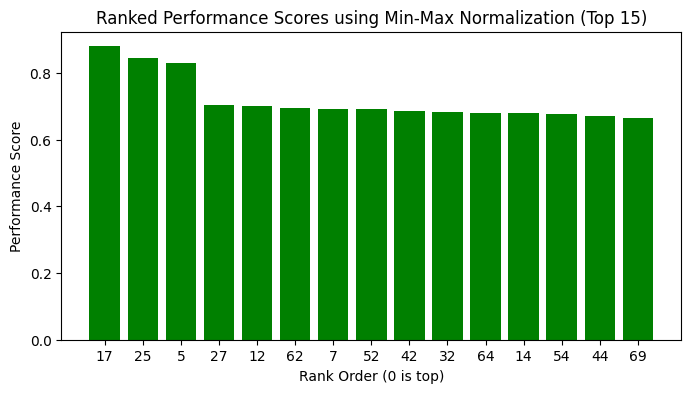

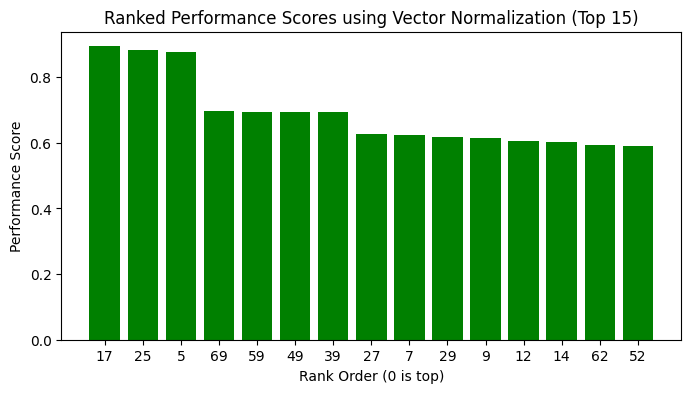

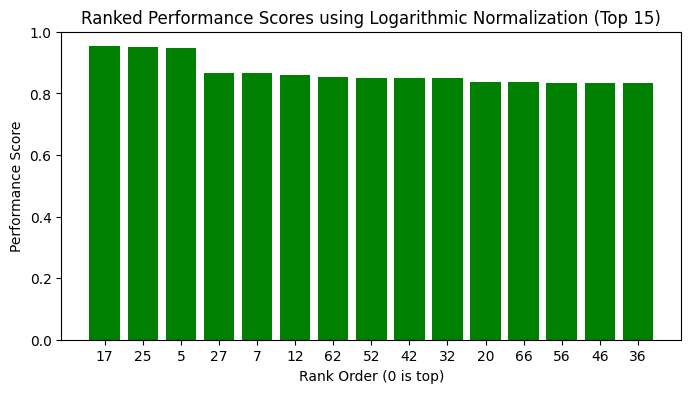

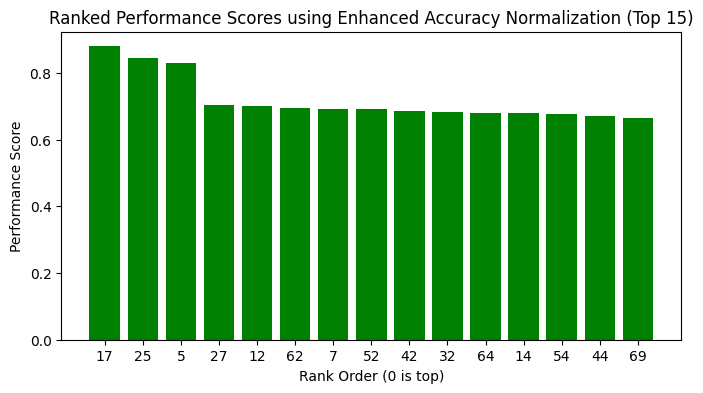

In [43]:
for method, result in results_70.items():
    # Get the ranking order of alternatives
    rank_order = result['rank_order']
    # Slice only the top 15 entries
    top15_rank_order = rank_order[:15]
    top15_scores = result['performance_scores'][top15_rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(top15_rank_order)), top15_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization (Top 15)')
    plt.xticks(range(len(top15_rank_order)), top15_rank_order)  # Label bars with the alternative indices
    plt.show()


Node == 80

In [44]:
import numpy as np

# --- Previous 40 data points ---
raw_da_40 = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"],           # Node 20
    [320, 32, 16, "Excellent"],      # Node 21
    [215, 16, 8, "Average"],         # Node 22
    [305, 32, 12, "Good"],           # Node 23
    [265, 16, 16, "Good"],           # Node 24
    [230, 8, 8, "Below Average"],    # Node 25
    [330, 64, 20, "Excellent"],      # Node 26
    [190, 8, 12, "Poor"],            # Node 27
    [300, 32, 24, "Excellent"],      # Node 28
    [245, 16, 16, "Good"],           # Node 29
    [355, 64, 8, "Average"],         # Node 30
    [265, 16, 10, "Good"],           # Node 31
    [240, 8, 8, "Below Average"],    # Node 32
    [340, 32, 18, "Excellent"],      # Node 33
    [280, 16, 14, "Average"],        # Node 34
    [310, 32, 20, "Good"],           # Node 35
    [205, 16, 10, "Poor"],           # Node 36
    [295, 32, 16, "Excellent"],      # Node 37
    [225, 8, 12, "Below Average"],   # Node 38
    [315, 32, 14, "Good"],           # Node 39
    [355, 64, 10, "Excellent"]       # Node 40
]

# --- Fabricated nodes to bring total from 40 to 50 ---
fabricated_nodes_50 = [
    [265, 16, 12, "Good"],           # Node 41
    [205, 8, 10, "Below Average"],   # Node 42
    [345, 32, 18, "Excellent"],      # Node 43
    [280, 16, 12, "Average"],        # Node 44
    [315, 32, 22, "Good"],           # Node 45
    [210, 16, 14, "Poor"],           # Node 46
    [295, 32, 16, "Excellent"],      # Node 47
    [230, 8, 12, "Below Average"],   # Node 48
    [320, 32, 14, "Good"],           # Node 49
    [360, 64, 10, "Excellent"]       # Node 50
]

# Use the previous data to create raw_da_50 without redundancy
raw_da_50 = raw_da_40.copy()  # Copy the original 40 nodes
raw_da_50.extend(fabricated_nodes_50)  # Append nodes 41-50

# --- Fabricate 30 additional nodes (Nodes 51 to 80) ---
fabricated_nodes_80 = [
    [270, 16, 12, "Good"],           # Node 51
    [210, 8, 10, "Below Average"],   # Node 52
    [350, 32, 18, "Excellent"],      # Node 53
    [285, 16, 12, "Average"],        # Node 54
    [320, 32, 22, "Good"],           # Node 55
    [215, 16, 14, "Poor"],           # Node 56
    [300, 32, 16, "Excellent"],      # Node 57
    [235, 8, 12, "Below Average"],   # Node 58
    [325, 32, 14, "Good"],           # Node 59
    [365, 64, 10, "Excellent"],      # Node 60
    [275, 16, 12, "Good"],           # Node 61
    [215, 8, 10, "Below Average"],   # Node 62
    [355, 32, 18, "Excellent"],      # Node 63
    [290, 16, 12, "Average"],        # Node 64
    [325, 32, 22, "Good"],           # Node 65
    [220, 16, 14, "Poor"],           # Node 66
    [305, 32, 16, "Excellent"],      # Node 67
    [240, 8, 12, "Below Average"],   # Node 68
    [330, 32, 14, "Good"],           # Node 69
    [370, 64, 10, "Excellent"],      # Node 70
    [280, 16, 12, "Good"],           # Node 71
    [220, 8, 10, "Below Average"],   # Node 72
    [360, 32, 18, "Excellent"],      # Node 73
    [295, 16, 12, "Average"],        # Node 74
    [330, 32, 22, "Good"],           # Node 75
    [225, 16, 14, "Poor"],           # Node 76
    [310, 32, 16, "Excellent"],      # Node 77
    [245, 8, 12, "Below Average"],   # Node 78
    [335, 32, 14, "Good"],           # Node 79
    [375, 64, 10, "Excellent"]       # Node 80
]

# Append the additional 30 nodes to the 50-node data to get a total of 80 nodes
raw_da_50.extend(fabricated_nodes_80)

# --- Mapping for the qualitative "Looks" column ---
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}

# --- Encode the complete data into numeric format ---
encoded_da = []  # Start with an empty list

for row in raw_da_50:
    battery_capacity = row[0]
    environmental = row[1]
    bandwidth = row[2]
    link_quality = looks_mapping[row[3]]  # Convert qualitative rating to numeric
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

# Convert the encoded list to a NumPy array
da_80 = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix (80 nodes):\n", da_80)
print("Shape of data matrix:", da_80.shape)


Encoded Data Matrix (80 nodes):
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]
 [320.  32.  16.   5.]
 [215.  16.   8.   3.]
 [305.  32.  12.   4.]
 [265.  16.  16.   4.]
 [230.   8.   8.   2.]
 [330.  64.  20.   5.]
 [190.   8.  12.   1.]
 [300.  32.  24.   5.]
 [245.  16.  16.   4.]
 [355.  64.   8.   3.]
 [265.  16.  10.   4.]
 [240.   8.   8.   2.]
 [340.  32.  18.   5.]
 [280.  16.  14.   3.]
 [310.  32.  20.   4.]
 [205.  16.  10.   1.]
 [295.  32.  16.   5.]
 [225.   8.  12.   2.]
 [315.  32.  14.   4.]
 [355.  64.  10.   5.]
 [265.  16.  12.   4.]
 [205.   8.  10.   2.]
 

In [45]:
results_80 = calculates_all(da_80, normalization_methods, is_beneficial)

for method, result in results_80.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.35897436 0.85714286 0.25       1.        ]
 [0.1025641  0.85714286 0.         0.5       ]
 [0.61538462 0.57142857 0.5        0.75      ]
 [0.48717949 0.57142857 0.         0.75      ]
 [0.23076923 0.85714286 0.5        0.25      ]
 [0.71794872 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.56410256 0.57142857 1.         1.        ]
 [0.30769231 0.85714286 0.5        0.75      ]
 [0.87179487 0.         0.         0.5       ]
 [0.41025641 0.85714286 0.25       0.75      ]
 [0.15384615 1.         0.         0.25      ]
 [0.76923077 0.57142857 0.75       1.        ]
 [0.48717949 0.85714286 0.5        0.5       ]
 [0.66666667 0.57142857 1.         0.75      ]
 [0.07692308 1.         0.25       0.        ]
 [0.53846154 0.85714286 0.5        0.75      ]
 [0.92307692 0.         0.75       1.        ]
 [0.25641026 0.85714286 0.         0.25      ]
 [0.66666667 0.57142857 0.25       0.75      ]
 [0.71794872

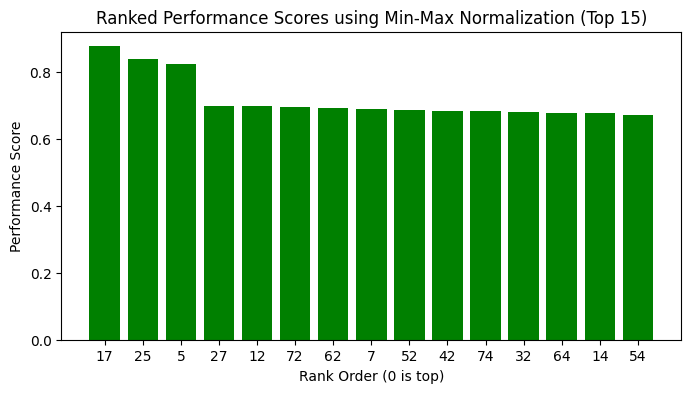

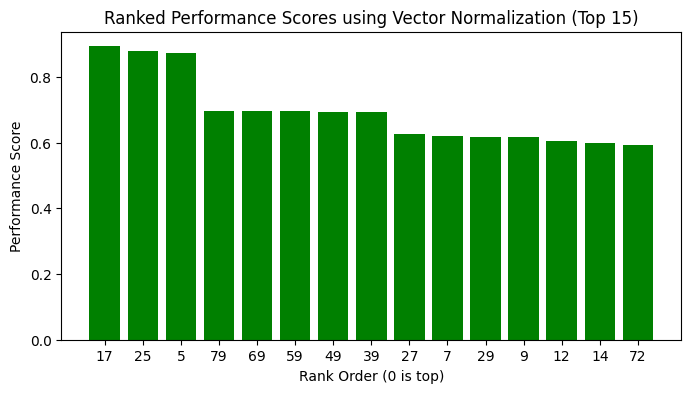

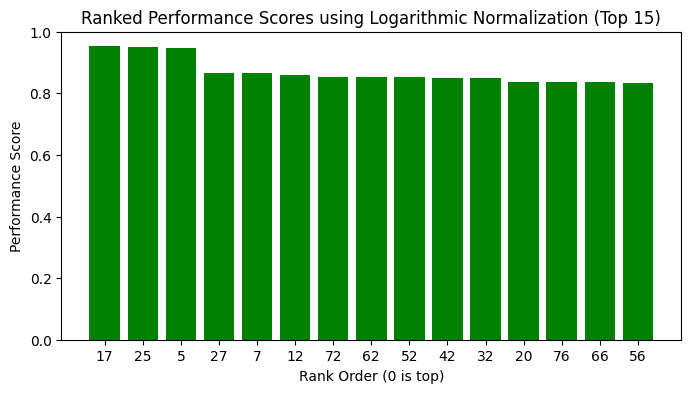

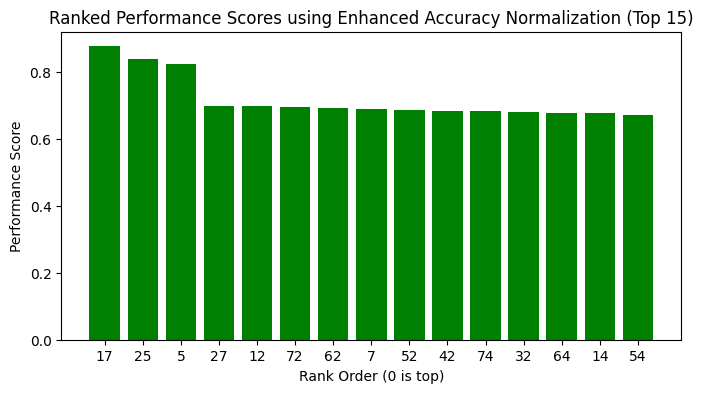

In [46]:
for method, result in results_80.items():
    # Get the ranking order of alternatives
    rank_order = result['rank_order']
    # Slice only the top 15 entries
    top15_rank_order = rank_order[:15]
    top15_scores = result['performance_scores'][top15_rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(top15_rank_order)), top15_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization (Top 15)')
    plt.xticks(range(len(top15_rank_order)), top15_rank_order)  # Label bars with the alternative indices
    plt.show()


Node == 100

In [47]:
import numpy as np

# --- Previous 40 data points ---
raw_da_40 = [
    [250, 16, 12, "Excellent"],      # Node 1
    [200, 16, 8, "Average"],         # Node 2
    [300, 32, 16, "Good"],           # Node 3
    [275, 32, 8, "Good"],            # Node 4
    [225, 16, 16, "Below Average"],  # Node 5
    [320, 64, 20, "Excellent"],      # Node 6
    [180, 8, 12, "Poor"],            # Node 7
    [290, 32, 24, "Excellent"],      # Node 8
    [240, 16, 16, "Good"],           # Node 9
    [350, 64, 8, "Average"],         # Node 10
    [260, 16, 12, "Good"],           # Node 11
    [210, 8, 8, "Below Average"],    # Node 12
    [330, 32, 20, "Excellent"],      # Node 13
    [275, 16, 16, "Average"],        # Node 14
    [310, 32, 24, "Good"],           # Node 15
    [195, 8, 12, "Poor"],            # Node 16
    [285, 16, 16, "Good"],           # Node 17
    [360, 64, 20, "Excellent"],      # Node 18
    [230, 16, 8, "Below Average"],   # Node 19
    [310, 32, 12, "Good"],           # Node 20
    [320, 32, 16, "Excellent"],      # Node 21
    [215, 16, 8, "Average"],         # Node 22
    [305, 32, 12, "Good"],           # Node 23
    [265, 16, 16, "Good"],           # Node 24
    [230, 8, 8, "Below Average"],    # Node 25
    [330, 64, 20, "Excellent"],      # Node 26
    [190, 8, 12, "Poor"],            # Node 27
    [300, 32, 24, "Excellent"],      # Node 28
    [245, 16, 16, "Good"],           # Node 29
    [355, 64, 8, "Average"],         # Node 30
    [265, 16, 10, "Good"],           # Node 31
    [240, 8, 8, "Below Average"],    # Node 32
    [340, 32, 18, "Excellent"],      # Node 33
    [280, 16, 14, "Average"],        # Node 34
    [310, 32, 20, "Good"],           # Node 35
    [205, 16, 10, "Poor"],           # Node 36
    [295, 32, 16, "Excellent"],      # Node 37
    [225, 8, 12, "Below Average"],   # Node 38
    [315, 32, 14, "Good"],           # Node 39
    [355, 64, 10, "Excellent"]       # Node 40
]

# --- Fabricated nodes to bring total from 40 to 50 ---
fabricated_nodes_50 = [
    [265, 16, 12, "Good"],           # Node 41
    [205, 8, 10, "Below Average"],   # Node 42
    [345, 32, 18, "Excellent"],      # Node 43
    [280, 16, 12, "Average"],        # Node 44
    [315, 32, 22, "Good"],           # Node 45
    [210, 16, 14, "Poor"],           # Node 46
    [295, 32, 16, "Excellent"],      # Node 47
    [230, 8, 12, "Below Average"],   # Node 48
    [320, 32, 14, "Good"],           # Node 49
    [360, 64, 10, "Excellent"]       # Node 50
]

# Create the 50-node data by reusing previous data
raw_da_50 = raw_da_40.copy()      # Copy the original 40 nodes
raw_da_50.extend(fabricated_nodes_50)  # Append nodes 41-50

# --- Fabricated nodes to bring total from 50 to 80 ---
fabricated_nodes_80 = [
    [270, 16, 12, "Good"],           # Node 51
    [210, 8, 10, "Below Average"],   # Node 52
    [350, 32, 18, "Excellent"],      # Node 53
    [285, 16, 12, "Average"],        # Node 54
    [320, 32, 22, "Good"],           # Node 55
    [215, 16, 14, "Poor"],           # Node 56
    [300, 32, 16, "Excellent"],      # Node 57
    [235, 8, 12, "Below Average"],   # Node 58
    [325, 32, 14, "Good"],           # Node 59
    [365, 64, 10, "Excellent"],      # Node 60
    [275, 16, 12, "Good"],           # Node 61
    [215, 8, 10, "Below Average"],   # Node 62
    [355, 32, 18, "Excellent"],      # Node 63
    [290, 16, 12, "Average"],        # Node 64
    [325, 32, 22, "Good"],           # Node 65
    [220, 16, 14, "Poor"],           # Node 66
    [305, 32, 16, "Excellent"],      # Node 67
    [240, 8, 12, "Below Average"],   # Node 68
    [330, 32, 14, "Good"],           # Node 69
    [370, 64, 10, "Excellent"]       # Node 70
]

# Append the nodes to get 70 data points so far
raw_da_50.extend(fabricated_nodes_80)

# --- Fabricated nodes to bring total from 70 to 100 ---
fabricated_nodes_100 = [
    [280, 16, 12, "Good"],           # Node 71
    [220, 8, 10, "Below Average"],   # Node 72
    [360, 32, 18, "Excellent"],      # Node 73
    [295, 16, 12, "Average"],        # Node 74
    [330, 32, 22, "Good"],           # Node 75
    [225, 16, 14, "Poor"],           # Node 76
    [310, 32, 16, "Excellent"],      # Node 77
    [245, 8, 12, "Below Average"],   # Node 78
    [335, 32, 14, "Good"],           # Node 79
    [375, 64, 10, "Excellent"],      # Node 80
    [285, 16, 12, "Good"],           # Node 81
    [225, 8, 10, "Below Average"],   # Node 82
    [365, 32, 18, "Excellent"],      # Node 83
    [300, 16, 12, "Average"],        # Node 84
    [335, 32, 22, "Good"],           # Node 85
    [230, 16, 14, "Poor"],           # Node 86
    [315, 32, 16, "Excellent"],      # Node 87
    [250, 8, 12, "Below Average"],   # Node 88
    [340, 32, 14, "Good"],           # Node 89
    [380, 64, 10, "Excellent"]       # Node 90
]

# Now, we need to add 10 more nodes to bring the total from 90 to 100
additional_nodes = [
    [290, 16, 12, "Good"],           # Node 91
    [230, 8, 10, "Below Average"],   # Node 92
    [370, 32, 18, "Excellent"],      # Node 93
    [305, 16, 12, "Average"],        # Node 94
    [340, 32, 22, "Good"],           # Node 95
    [235, 16, 14, "Poor"],           # Node 96
    [320, 32, 16, "Excellent"],      # Node 97
    [255, 8, 12, "Below Average"],   # Node 98
    [345, 32, 14, "Good"],           # Node 99
    [385, 64, 10, "Excellent"]       # Node 100
]

# Append fabricated_nodes_100 and additional_nodes to complete 100 data points.
raw_da_50.extend(fabricated_nodes_100)
raw_da_50.extend(additional_nodes)

# --- Mapping for the "Looks" column ---
looks_mapping = {
    "Excellent": 5,
    "Good": 4,
    "Average": 3,
    "Below Average": 2,
    "Poor": 1
}

# --- Encode the complete data into numeric format ---
encoded_da = []  # Start with an empty list

for row in raw_da_50:
    battery_capacity = row[0]
    environmental = row[1]
    bandwidth = row[2]
    link_quality = looks_mapping[row[3]]  # Convert qualitative rating to numeric
    encoded_da.append([battery_capacity, environmental, bandwidth, link_quality])

# Convert the encoded list to a NumPy array
da_100 = np.array(encoded_da, dtype=float)
print("Encoded Data Matrix (100 nodes):\n", da_100)
print("Shape of data matrix:", da_100.shape)


Encoded Data Matrix (100 nodes):
 [[250.  16.  12.   5.]
 [200.  16.   8.   3.]
 [300.  32.  16.   4.]
 [275.  32.   8.   4.]
 [225.  16.  16.   2.]
 [320.  64.  20.   5.]
 [180.   8.  12.   1.]
 [290.  32.  24.   5.]
 [240.  16.  16.   4.]
 [350.  64.   8.   3.]
 [260.  16.  12.   4.]
 [210.   8.   8.   2.]
 [330.  32.  20.   5.]
 [275.  16.  16.   3.]
 [310.  32.  24.   4.]
 [195.   8.  12.   1.]
 [285.  16.  16.   4.]
 [360.  64.  20.   5.]
 [230.  16.   8.   2.]
 [310.  32.  12.   4.]
 [320.  32.  16.   5.]
 [215.  16.   8.   3.]
 [305.  32.  12.   4.]
 [265.  16.  16.   4.]
 [230.   8.   8.   2.]
 [330.  64.  20.   5.]
 [190.   8.  12.   1.]
 [300.  32.  24.   5.]
 [245.  16.  16.   4.]
 [355.  64.   8.   3.]
 [265.  16.  10.   4.]
 [240.   8.   8.   2.]
 [340.  32.  18.   5.]
 [280.  16.  14.   3.]
 [310.  32.  20.   4.]
 [205.  16.  10.   1.]
 [295.  32.  16.   5.]
 [225.   8.  12.   2.]
 [315.  32.  14.   4.]
 [355.  64.  10.   5.]
 [265.  16.  12.   4.]
 [205.   8.  10.   2.]


In [48]:
results_100 = calculates_all(da_100, normalization_methods, is_beneficial)

for method, result in results_100.items():
    print(f"\nNormalization method: {method}")
    for key, value in result.items():
        print(f"{key}: {value}")



Normalization method: Min-Max
normalized_data: [[0.34146341 0.85714286 0.25       1.        ]
 [0.09756098 0.85714286 0.         0.5       ]
 [0.58536585 0.57142857 0.5        0.75      ]
 [0.46341463 0.57142857 0.         0.75      ]
 [0.2195122  0.85714286 0.5        0.25      ]
 [0.68292683 0.         0.75       1.        ]
 [0.         1.         0.25       0.        ]
 [0.53658537 0.57142857 1.         1.        ]
 [0.29268293 0.85714286 0.5        0.75      ]
 [0.82926829 0.         0.         0.5       ]
 [0.3902439  0.85714286 0.25       0.75      ]
 [0.14634146 1.         0.         0.25      ]
 [0.73170732 0.57142857 0.75       1.        ]
 [0.46341463 0.85714286 0.5        0.5       ]
 [0.63414634 0.57142857 1.         0.75      ]
 [0.07317073 1.         0.25       0.        ]
 [0.51219512 0.85714286 0.5        0.75      ]
 [0.87804878 0.         0.75       1.        ]
 [0.24390244 0.85714286 0.         0.25      ]
 [0.63414634 0.57142857 0.25       0.75      ]
 [0.68292683

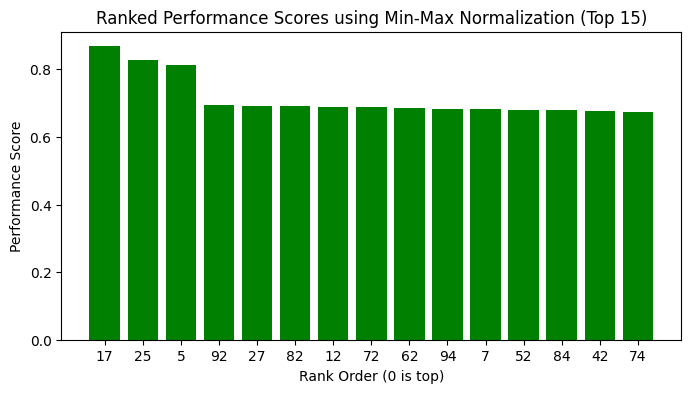

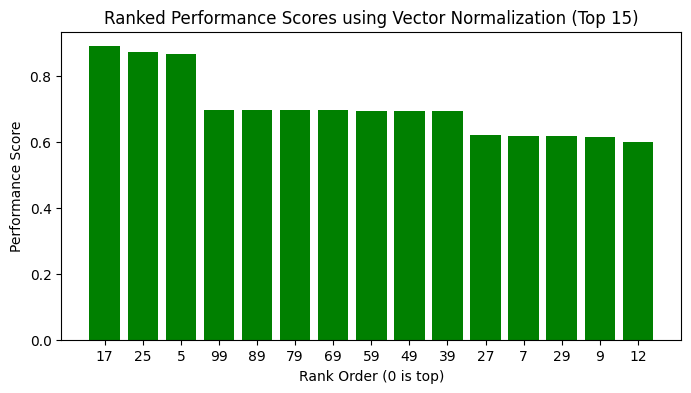

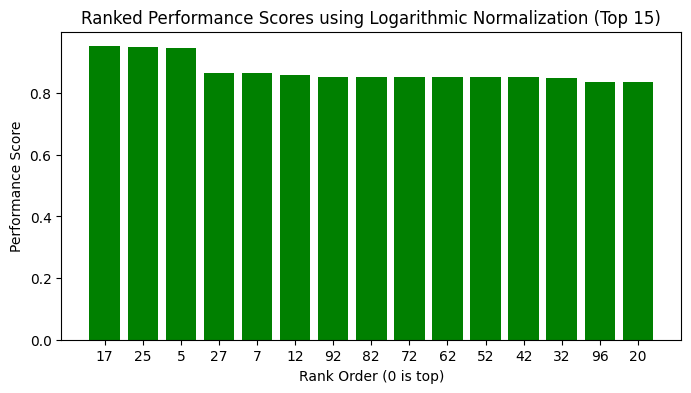

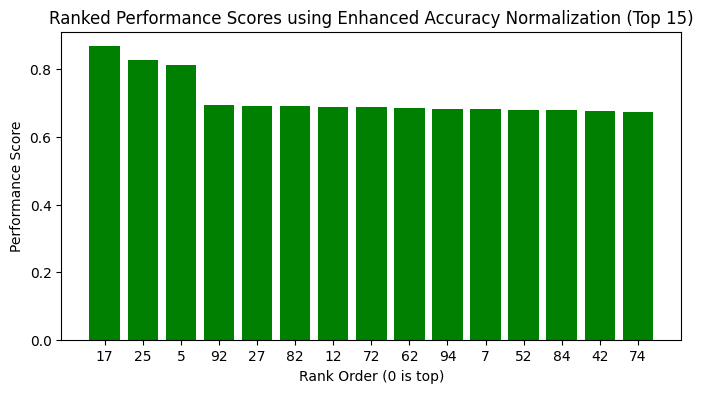

In [49]:
for method, result in results_100.items():
    # Get the ranking order of alternatives
    rank_order = result['rank_order']
    # Slice only the top 15 entries
    top15_rank_order = rank_order[:15]
    top15_scores = result['performance_scores'][top15_rank_order]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(top15_rank_order)), top15_scores, color='green')
    plt.xlabel('Rank Order (0 is top)')
    plt.ylabel('Performance Score')
    plt.title(f'Ranked Performance Scores using {method} Normalization (Top 15)')
    plt.xticks(range(len(top15_rank_order)), top15_rank_order)  # Label bars with the alternative indices
    plt.show()


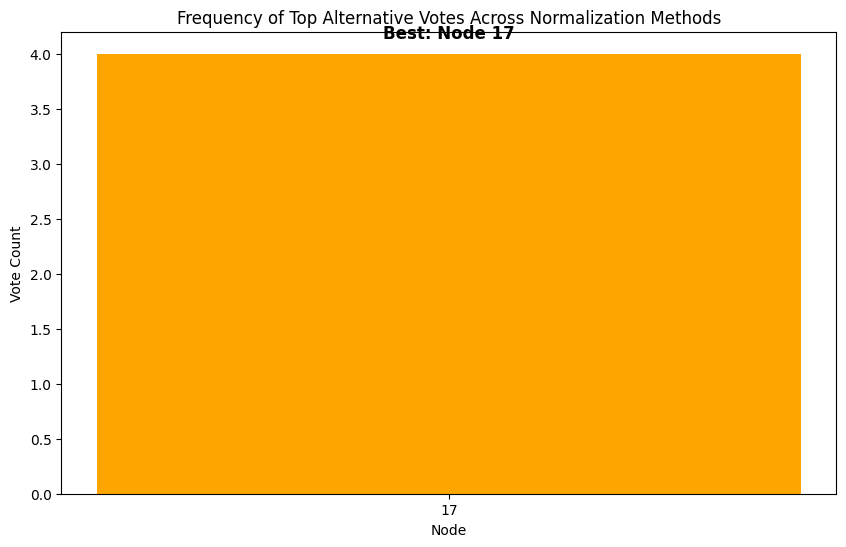

In [50]:
import matplotlib.pyplot as plt

def get_best_node(results):
    """
    Iterates over the TOPSIS results from different normalization methods
    and returns the node that is most frequently the top alternative.
    """
    votes = {}
    for method, result in results.items():
        top_node = result['top_alternatives'][0]
        votes[top_node] = votes.get(top_node, 0) + 1
    best_node = max(votes, key=votes.get)
    return best_node, votes

# Get the best node and vote counts from your TOPSIS results
best_node, vote_counts = get_best_node(results_100)

# Prepare data for visualization
nodes = list(vote_counts.keys())
counts = list(vote_counts.values())

# Create a color list to highlight the best node (e.g., best node in orange)
colors = ['orange' if node == best_node else 'skyblue' for node in nodes]

plt.figure(figsize=(10, 6))
plt.bar(nodes, counts, color=colors)
plt.xlabel("Node")
plt.ylabel("Vote Count")
plt.title("Frequency of Top Alternative Votes Across Normalization Methods")
plt.xticks(nodes)
plt.text(best_node, vote_counts[best_node] + 0.1, f"Best: Node {best_node}", 
         ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')
plt.show()


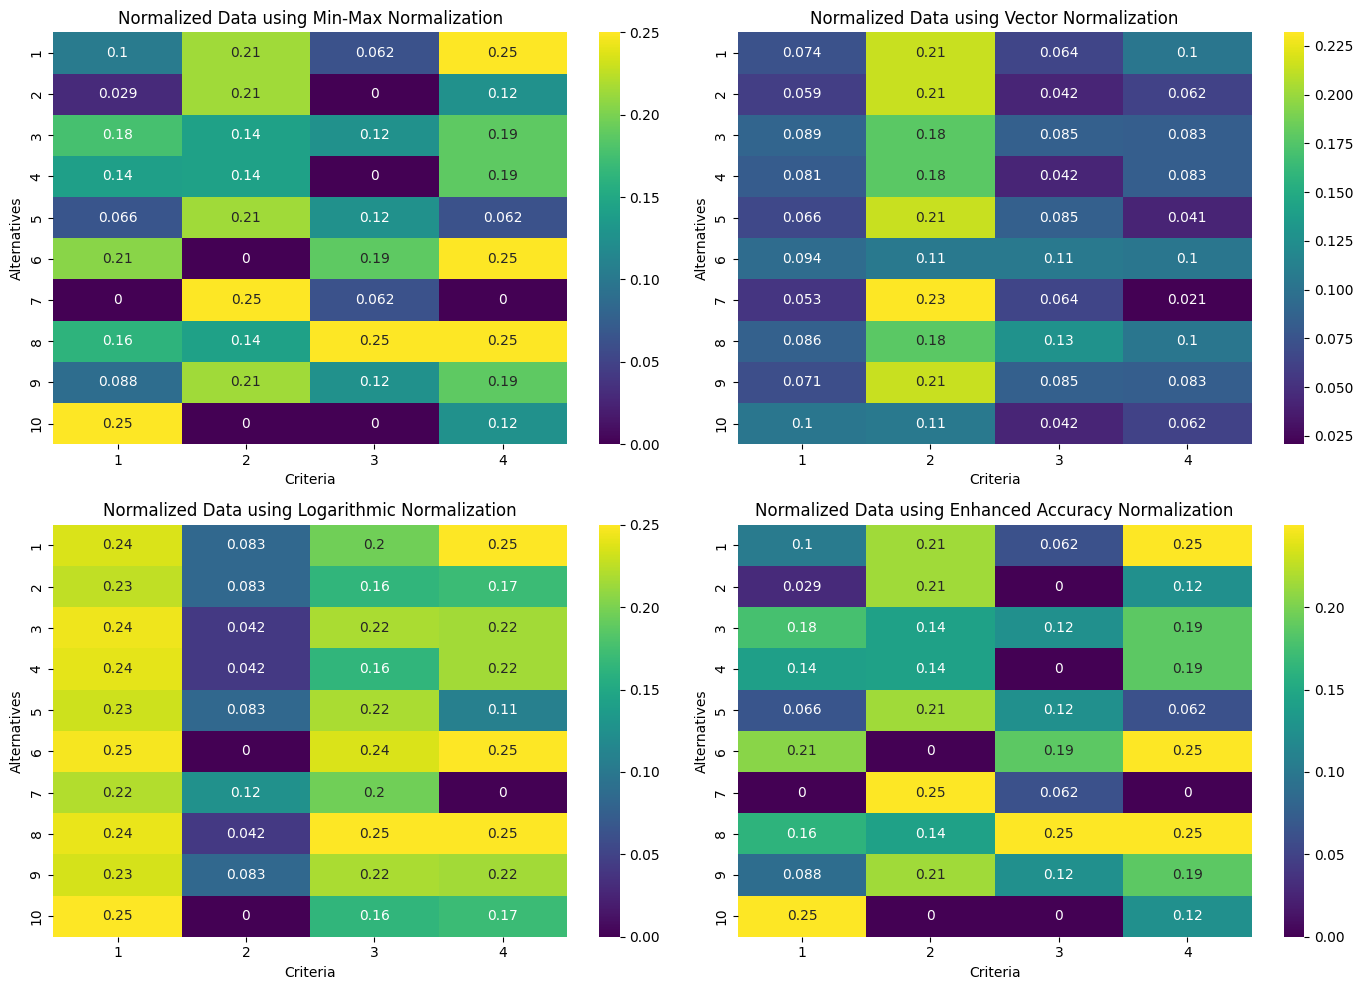

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Number of methods
n_methods = len(results)
cols = 2  # Adjust columns as needed
rows = (n_methods + cols - 1) // cols  # Compute rows to fit all plots

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()  # Flatten for easy iteration

for idx, (method, result) in enumerate(results.items()):
    norm_data = result['normalized_data']*weights
    
    # Update alternative labels to start from 1
    alt_labels = [f"{i+1}" for i in range(norm_data.shape[0])]
    crit_labels = [f"{j+1}" for j in range(norm_data.shape[1])]

    sns.heatmap(
        norm_data,
        annot=True,
        cmap='viridis',
        cbar=True,
        ax=axes[idx],
        xticklabels=crit_labels,
        yticklabels=alt_labels
    )
    axes[idx].set_xlabel('Criteria')
    axes[idx].set_ylabel('Alternatives')
    axes[idx].set_title(f'Normalized Data using {method} Normalization')

# Turn off any unused subplots
for ax in axes[n_methods:]:
    ax.axis('off')

plt.tight_layout()
plt.show()